# Analysis of Happiness by Country and The Major Factors Affecting It

## Background

It is no secret that the world we know today has a variety of issues. From the amount of division to people still being hungry in the 21st century, there seems to never be an end to these dire situations. Above it all, the first ones to suffer are always the citizens themselves. It is also no surprise that all of these events would have detrimental effects to one's mental health, but what are the most influential factors that alter happiness? My honest guess before even starting this project was war, since many other factors such as death and genocide could be involve in the midst of such chaotic events. However, I wanted to dive deeper than that. War would make anyone unhappy, but what about other aspects like a poor health care system or a crumbling economy? 

For this project I made a deep dive into various aspects of a country to really try and find the most influential aspects of citizen happiness. I will achieve this through a means of proper EDA, finding early trends amongst high performing and low performing countries, exploring patterns amongst the various aspects I will be looking at, and using k-means clustering to separate countries into different groups based on patterns in different categories based on data from 2023.

# Datasets Used

- [World Happiness Index](https://www.worldhappiness.report/): used to get data about happiness by country measured on a 1-10 scale, with 1 being unhappy and 10 being the happiest
- [World Data Set 2023](https://www.kaggle.com/datasets/nelgiriyewithana/countries-of-the-world-2023): pulled data such as CO2 emissions and other important information 
- [Crime Rate By Country 2023](https://www.kaggle.com/datasets/zabihullah18/crime-rate-by-country-2023): used to get the crime rates by country
- [Global Corruption Index 2023: Insights & Rankings](https://www.kaggle.com/datasets/agungpambudi/global-corruption-index-transparency-perceptions): Used to get the corruption data for each individual country 

## Vocabulary 

*All of this data will be from 2023 to keep consistency within the project

| Term    | Definition |
| -------- | ------- |
| Happiness Score  | An arbitrary rating system from 1-10 (1 being sad, 10 being very happy) to measure citizens' happiness in a given country |
| CO2-Emissions | Carbon dioxide emissions in tons |
| GDP ($)    | Gross domestic product of a country in dollars, in other words, value of all items and goods in a country|
| Infant Mortality    | Number of deaths of every 1,000 babies before the age of one |
| Unemployment Rate | Percentage of total labor that is unemployed in the nation |
| Out of Pocket Health Expenditure (%) | Percentage of total health expenditure paid out of pocket by citizens in the country |
| Crime Index | Arbitrary scale measuring how much crime occurs in a country, high numbers meaning there's a higher prevalence of crime|
| CPI Score | Corruption perceptions index (CPI) measuring how corrupt a country is, high numbers meaning it's not corrupt and fair |
| Physicians Per Thousand Citizens | Numbers of physicians for every thousand people in the country |

# Categories of Data

I plan to use k-means clustering, an unsupervised machine learning algorithm where data is sorted into separate categories based on patterns found within the data. A popular issue that comes with this is the dimensionality issue, where too many variables can make the algorithm struggle with taking too many variables into account. Judging from the table above, I will most likely run into this issue. To combat this, I decided to sort them into similar categories to focus my analysis in smaller groups as well as being able to use k-means clustering in this project. These categories can be seen below:

**Independent Variables**  
| Category | Variables Included|
| -------- | ------| 
| Healthcare | Out of Pocket Health Expenditure (%), Physicians Per Thousand Citizens, CO2-Emissions| 
| Citizen Safety | Infant Mortality, Crime Index, CPI Score |
| Economics | Unemployment Rate, GDP ($)|

**Dependent Variable**
- Happiness Score is the only variable measured in this project

# Libraries

In [1]:
#Basic Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import math

#Machine Learning Tools 
import sklearn as sk 
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

## Dataframe Processing
Reading in the datasets mentioned above, connecting them together, and pulling exclusively the information needed for this project.  

In [2]:
worldHappiness = pd.read_excel('assets/World_Happiness_2023.xls') 
worldHappiness.head()

,Country name,Ladder score,Standard error of ladder score,upperwhisker,lowerwhisker,Logged GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,Ladder score in Dystopia,Explained by: Log GDP per capita,Explained by: Social support,Explained by: Healthy life expectancy,Explained by: Freedom to make life choices,Explained by: Generosity,Explained by: Perceptions of corruption,Dystopia + residual
0,Finland,7.8042,0.036162,7.875078,7.733322,10.792010,0.968770,71.149994,0.961408,-0.018824,0.181745,1.777825,1.888380,1.584900,0.534574,0.771510,0.126331,0.535299,2.363241
1,Denmark,7.5864,0.041028,7.666815,7.505985,10.962164,0.954112,71.250145,0.933533,0.134242,0.195814,1.777825,1.949406,1.547875,0.537302,0.734416,0.208459,0.525221,2.083766
2,Iceland,7.5296,0.048612,7.624879,7.434321,10.895531,0.982533,72.050018,0.936349,0.210987,0.667848,1.777825,1.925508,1.619666,0.559096,0.738164,0.249635,0.187119,2.250382
3,Israel,7.4729,0.031609,7.534853,7.410946,10.638705,0.943344,72.697205,0.808866,-0.023080,0.708094,1.777825,1.833398,1.520674,0.576730,0.568518,0.124048,0.158292,2.691290
4,Netherlands,7.4030,0.029294,7.460416,7.345583,10.942279,0.930499,71.550018,0.886875,0.212686,0.378929,1.777825,1.942274,1.488228,0.545473,0.672327,0.250547,0.394062,2.110044


In [3]:
worldHappiness.shape

(137, 19)

In [4]:
countryInformation = pd.read_csv('assets/World_Data_2023.csv')
countryInformation.head()

,Country,Density\n(P/Km2),Abbreviation,Agricultural Land( %),Land Area(Km2),Armed Forces size,Birth Rate,Calling Code,Capital/Major City,Co2-Emissions,...,Out of pocket health expenditure,Physicians per thousand,Population,Population: Labor force participation (%),Tax revenue (%),Total tax rate,Unemployment rate,Urban_population,Latitude,Longitude
0,Afghanistan,60,AF,58.10%,"652,230","323,000",32.49,93.0,Kabul,"8,672",...,78.40%,0.28,"38,041,754",48.90%,9.30%,71.40%,11.12%,"9,797,273",33.939110,67.709953
1,Albania,105,AL,43.10%,"28,748","9,000",11.78,355.0,Tirana,"4,536",...,56.90%,1.20,"2,854,191",55.70%,18.60%,36.60%,12.33%,"1,747,593",41.153332,20.168331
2,Algeria,18,DZ,17.40%,"2,381,741","317,000",24.28,213.0,Algiers,"150,006",...,28.10%,1.72,"43,053,054",41.20%,37.20%,66.10%,11.70%,"31,510,100",28.033886,1.659626
3,Andorra,164,AD,40.00%,468,NaN,7.20,376.0,Andorra la Vella,469,...,36.40%,3.33,"77,142",NaN,NaN,NaN,NaN,"67,873",42.506285,1.521801
4,Angola,26,AO,47.50%,"1,246,700","117,000",40.73,244.0,Luanda,"34,693",...,33.40%,0.21,"31,825,295",77.50%,9.20%,49.10%,6.89%,"21,061,025",-11.202692,17.873887


In [5]:
countryInformation.shape

(195, 35)

In [6]:
crimeDf = pd.read_csv('assets/Crime_Rates_2023.csv')
crimeDf.head()

,rank,country,crimeIndex,pop2023
0,1,Venezuela,83.76,28838499.0
1,2,Papua New Guinea,80.79,10329931.0
2,3,South Africa,76.86,60414495.0
3,4,Afghanistan,76.31,42239854.0
4,5,Honduras,74.54,10593798.0


In [7]:
corruption_df = pd.read_csv('assets/Corruption_Data.csv', sep = '|')
corruption_df.head()

,Country / Territory,ISO3,Region,CPI score 2023,Rank,Standard error,Number of sources,Lower CI,Upper CI,African Development Bank CPIA,...,Economist Intelligence Unit Country Ratings,Freedom House Nations in Transit,Global Insights Country Risk Ratings,IMD World Competitiveness Yearbook,PERC Asia Risk Guide,PRS International Country Risk Guide,Varieties of Democracy Project,World Bank CPIA,World Economic Forum EOS,World Justice Project Rule of Law Index
0,Denmark,DNK,WE/EU,90,1,1.819265,8,87.01640,92.98360,NaN,...,89.67447,NaN,83.25637,97.89119,NaN,100.00000,78.89152,NaN,82.20667,87.68097
1,Finland,FIN,WE/EU,87,2,1.057962,8,85.26495,88.73505,NaN,...,89.67447,NaN,83.25637,89.84466,NaN,93.38018,78.16811,NaN,86.76612,85.88441
2,New Zealand,NZL,AP,85,3,1.916107,8,81.85758,88.14242,NaN,...,89.67447,NaN,83.25637,87.10542,NaN,93.38018,78.16811,NaN,70.98344,82.29130
3,Norway,NOR,WE/EU,84,4,1.380803,7,81.73548,86.26452,NaN,...,89.67447,NaN,83.25637,75.72045,NaN,84.67139,78.16811,NaN,NaN,86.78268
4,Singapore,SGP,AP,83,5,1.145734,9,81.12099,84.87901,NaN,...,89.67447,NaN,83.25637,76.74767,89.29896,83.27798,78.16811,NaN,88.51975,84.08785


In [8]:
#Rename column titles for convenience during merging
crimeDf = crimeDf.rename(columns = {'country' : 'Country'})
worldHappiness = worldHappiness.rename(columns = {'Country name' : 'Country'})
corruption_df = corruption_df.rename(columns = {'Country / Territory' : 'Country'})

#### Renaming Countries

A huge issue when it comes to analyzing data involving geography is making sure all countries are named the same, especially since many of them could have different names (ex: Czechia versus Czech Republic, Ivory Coast versus Cote d'Ivoire, etc). The following cells show how I overcame that issue.

In [9]:
#Find every single mismatched country name between sets 
all_dataframes = [crimeDf, worldHappiness, corruption_df, countryInformation]
mismatched_country_names = set() 

#O(n^2) speed, not the most efficient, but gives a decent idea of what countries have differing names
for a in all_dataframes:
    for b in all_dataframes:
        if not a.equals(b): 
            mismatched_country_names.update(set(a['Country']) - set(b['Country']))

for c in mismatched_country_names:
    print(c)
            

Burundi
Senegal
Congo (Kinshasa)
Brunei
South Korea
Chad
Eritrea
Korea South
Taiwan Province of China
Taiwan
Kuwait
Hong Kong S.A.R. of China
Guinea-Bissau
Saint Lucia
Vatican City
Fiji
Nauru
Korea North
State of Palestine
Palau
Bahamas
Bosnia and Herzegovina
Yemen
Czechia
Trinidad and Tobago
Sudan
Turkey
Mali
Gambia
Guyana
Timor-Leste
Mauritania
Eswatini
Oman
Republic of Ireland
Congo
Equatorial Guinea
Madagascar
Vanuatu
Cabo Verde
The Gambia
Kiribati
Marshall Islands
Palestinian National Authority
East Timor
Puerto Rico
Saint Kitts and Nevis
Tonga
Samoa
Gabon
Cuba
Guinea
Kosovo
Papua New Guinea
Liberia
Libya
Belarus
Niger
Bhutan
Maldives
Turkmenistan
Rwanda
Andorra
Djibouti
Malawi
Saint Vincent and the Grenadines
Benin
Azerbaijan
North Korea
Congo (Brazzaville)
Seychelles
Mozambique
Burkina Faso
Comoros
Sierra Leone
Hong Kong
Barbados
Solomon Islands
S�����������
Palestine
South Sudan
Democratic Republic of the Congo
Lesotho
Haiti
San Marino
Tajikistan
Ireland
Togo
Cape Verde
Federat

In [10]:
#Dictionary with desired name changes after using information from above 
country_name_dict = {
    'Congo (Kinshasa)': 'Democratic Republic of the Congo', 
    'Congo (Brazzaville)' : 'Republic of the Congo', 
    'State of Palestine' :'Palestine', 
    'Palestinian National Authority' : 'Palestine', 
    'Hong Kong S.A.R. of China' : 'Hong Kong',
    'Turkey' : 'Turkiye',
    'Taiwan Province of China' : 'Taiwan',
    'Korea North' : 'North Korea',
    'Korea South' : 'South Korea',
    'Czech Republic' : 'Czechia', 
    'Republic of Ireland' : 'Ireland', 
    'Hong Kong S.A.R. of China' : 'Hong Kong',
    'Côte d\'Ivoire' : 'Ivory Coast' 
}

#Function that checks if a country needs to be renamed, otherwise, just strip 
rename_function = (lambda x : 
                   country_name_dict[x] if x in country_name_dict 
                   else x.strip())

In [11]:
#Apply previously defined function 
crimeDf['Country'] = crimeDf['Country'].apply(rename_function)
worldHappiness['Country'] = worldHappiness['Country'].apply(rename_function) 
corruption_df['Country'] = corruption_df['Country'].apply(rename_function) 
countryInformation['Country'] = countryInformation['Country'].apply(rename_function) 


#### Merging Dataframes Together

In [12]:
#Take in the data we want from the worldHappiness dataframe, kickstarts the completeDf, which 
completeDf = worldHappiness[['Country', 'Ladder score']]
completeDf = completeDf.sort_values(by = 'Country')

#Merge completeDf with crimeDf
countryInformation = countryInformation[['Country', 'Co2-Emissions', 'GDP', 'Infant mortality', 'Out of pocket health expenditure', 'Physicians per thousand', 'Unemployment rate']]
completeDf = pd.merge(completeDf, countryInformation, on = 'Country')


crimeDf = crimeDf[['Country', 'crimeIndex']]
completeDf = pd.merge(completeDf, crimeDf, on = 'Country')

#Merge corruption data with completeDf
corruption_df = corruption_df[['Country', 'CPI score 2023']]
completeDf = pd.merge(completeDf, corruption_df, on = 'Country')

completeDf.head()

,Country,Ladder score,Co2-Emissions,GDP,Infant mortality,Out of pocket health expenditure,Physicians per thousand,Unemployment rate,crimeIndex,CPI score 2023
0,Afghanistan,1.8590,"8,672","$19,101,353,833",47.9,78.40%,0.28,11.12%,76.31,20
1,Albania,5.2773,"4,536","$15,278,077,447",7.8,56.90%,1.20,12.33%,42.53,37
2,Algeria,5.3291,"150,006","$169,988,236,398",20.1,28.10%,1.72,11.70%,52.03,36
3,Argentina,6.0237,"201,348","$449,663,446,954",8.8,17.60%,3.96,9.79%,63.82,37
4,Armenia,5.3417,"5,156","$13,672,802,158",11.0,81.60%,4.40,16.99%,22.79,47


In [13]:
completeDf = completeDf.rename(columns = {
    'Ladder score' : 'Happiness Score', 
    'crimeIndex' : 'Crime Index',
    'Co2-Emissions' : 'CO2-Emissions', 
    'GDP' : 'GDP ($)', 
    'Infant mortality' : 'Infant Mortality',
    'Out of pocket health expenditure' : 'Out of Pocket Health Expenditure (%)', 
    'Physicians per thousand' : 'Physicians Per Thousand Citizens', 
    'Unemployment rate' : 'Unemployment Rate',
    'CPI score 2023' : 'CPI Score'
    })

completeDf.head()

,Country,Happiness Score,CO2-Emissions,GDP ($),Infant Mortality,Out of Pocket Health Expenditure (%),Physicians Per Thousand Citizens,Unemployment Rate,Crime Index,CPI Score
0,Afghanistan,1.8590,"8,672","$19,101,353,833",47.9,78.40%,0.28,11.12%,76.31,20
1,Albania,5.2773,"4,536","$15,278,077,447",7.8,56.90%,1.20,12.33%,42.53,37
2,Algeria,5.3291,"150,006","$169,988,236,398",20.1,28.10%,1.72,11.70%,52.03,36
3,Argentina,6.0237,"201,348","$449,663,446,954",8.8,17.60%,3.96,9.79%,63.82,37
4,Armenia,5.3417,"5,156","$13,672,802,158",11.0,81.60%,4.40,16.99%,22.79,47


In [14]:
print("Final DataFrame Shape: ", completeDf.shape)

Final DataFrame Shape:  (110, 10)


## Cleaning and Tidying Data

In any other project, it would be ideal to replace NaN values with an alternate value such as true or 0. However, implementing something like this for this project would be unreasonable since a 0 would very easily skew the data and as a result, causing the algorithms to produce inaccurate results. For this reason, I decided to drop any country that didn't have enough data to fill all the columns. 

In [15]:
#Drop countries that do not have enough data 
completeDf = completeDf.dropna()
completeDf = completeDf.reset_index(drop = True)
completeDf.head()

,Country,Happiness Score,CO2-Emissions,GDP ($),Infant Mortality,Out of Pocket Health Expenditure (%),Physicians Per Thousand Citizens,Unemployment Rate,Crime Index,CPI Score
0,Afghanistan,1.8590,"8,672","$19,101,353,833",47.9,78.40%,0.28,11.12%,76.31,20
1,Albania,5.2773,"4,536","$15,278,077,447",7.8,56.90%,1.20,12.33%,42.53,37
2,Algeria,5.3291,"150,006","$169,988,236,398",20.1,28.10%,1.72,11.70%,52.03,36
3,Argentina,6.0237,"201,348","$449,663,446,954",8.8,17.60%,3.96,9.79%,63.82,37
4,Armenia,5.3417,"5,156","$13,672,802,158",11.0,81.60%,4.40,16.99%,22.79,47


In [16]:
completeDf.shape

(109, 10)

In [17]:
#Check the datatypes of all columns 
completeDf.dtypes

Country                                  object
Happiness Score                         float64
CO2-Emissions                            object
GDP ($)                                  object
Infant Mortality                        float64
Out of Pocket Health Expenditure (%)     object
Physicians Per Thousand Citizens        float64
Unemployment Rate                        object
Crime Index                             float64
CPI Score                                 int64
dtype: object

Ideally, it would be better if all of these values were either floats or ints. We want to treat and analyze these values as actual numbers, not strings or objects. 

In [18]:
#Function for eliminating all symbols present in the dataframe 
symbol_stripper = lambda cell: str(cell).replace(',', '').replace('$', '').replace('%', '')

#Change the data type for each column where it is appropriate 
completeDf['GDP ($)'] = completeDf['GDP ($)'].apply(symbol_stripper)
completeDf['GDP ($)'] = completeDf['GDP ($)'].astype(float)

completeDf['Out of Pocket Health Expenditure (%)'] = completeDf['Out of Pocket Health Expenditure (%)'].apply(symbol_stripper)
completeDf['Out of Pocket Health Expenditure (%)'] = completeDf['Out of Pocket Health Expenditure (%)'].astype(float)

completeDf['Unemployment Rate'] = completeDf['Unemployment Rate'].apply(symbol_stripper)
completeDf['Unemployment Rate'] = completeDf['Unemployment Rate'].astype(float)

completeDf['CO2-Emissions'] = completeDf['CO2-Emissions'].apply(symbol_stripper)
completeDf['CO2-Emissions'] = completeDf['CO2-Emissions'].astype(np.int64)


completeDf.head()

,Country,Happiness Score,CO2-Emissions,GDP ($),Infant Mortality,Out of Pocket Health Expenditure (%),Physicians Per Thousand Citizens,Unemployment Rate,Crime Index,CPI Score
0,Afghanistan,1.8590,8672,1.910135e+10,47.9,78.4,0.28,11.12,76.31,20
1,Albania,5.2773,4536,1.527808e+10,7.8,56.9,1.20,12.33,42.53,37
2,Algeria,5.3291,150006,1.699882e+11,20.1,28.1,1.72,11.70,52.03,36
3,Argentina,6.0237,201348,4.496634e+11,8.8,17.6,3.96,9.79,63.82,37
4,Armenia,5.3417,5156,1.367280e+10,11.0,81.6,4.40,16.99,22.79,47


In [19]:
#Revist types 
completeDf.dtypes

Country                                  object
Happiness Score                         float64
CO2-Emissions                             int64
GDP ($)                                 float64
Infant Mortality                        float64
Out of Pocket Health Expenditure (%)    float64
Physicians Per Thousand Citizens        float64
Unemployment Rate                       float64
Crime Index                             float64
CPI Score                                 int64
dtype: object

## Exploratory Data Analysis (EDA)

After cleaning up the data and removing any discrepancies, we can now begin to look at common patterns shared in the data. 

In [20]:
#Get a picture of the most common stats and stuff
completeDf.describe().round(2)

,Happiness Score,CO2-Emissions,GDP ($),Infant Mortality,Out of Pocket Health Expenditure (%),Physicians Per Thousand Citizens,Unemployment Rate,Crime Index,CPI Score
count,109.00,109.00,1.090000e+02,109.00,109.00,109.00,109.00,109.00,109.00
mean,5.76,298914.07,8.316522e+11,13.57,33.58,2.32,6.77,44.59,47.34
std,1.11,1087501.24,2.845394e+12,13.49,18.06,1.53,4.73,14.13,19.12
min,1.86,1342.00,5.494737e+09,1.40,5.30,0.01,0.68,15.23,13.00
25%,5.11,10715.00,3.876047e+10,3.60,17.90,0.98,3.85,33.42,34.00
50%,5.95,41155.00,1.609672e+11,7.80,31.80,2.36,5.36,45.15,42.00
75%,6.47,201348.00,4.463147e+11,19.20,43.70,3.27,8.80,53.77,61.00
max,7.80,9893038.00,2.142770e+13,75.70,81.60,7.12,28.18,83.76,90.00


### Happiness Score 

#### Top 10 Happiest Countries 

/var/folders/9t/smb8cb7j223dk4xdg983zqmw0000gn/T/ipykernel_7293/1917408950.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


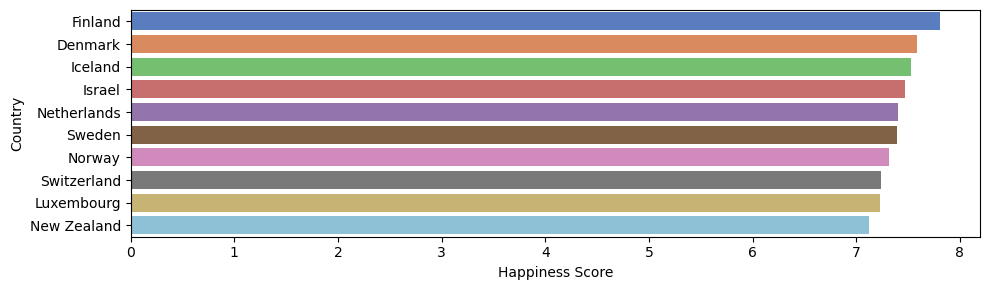

In [21]:
#Bar Plot showing the happiness score for all countries 
f, ax = plt.subplots(figsize=(10, 3))

highest_ten = completeDf.nlargest(n = 10, columns = 'Happiness Score').sort_values(ascending = False, by = 'Happiness Score')

sns.barplot(
    data = highest_ten, 
    x = "Happiness Score", 
    y = "Country", 
    legend = False,
    palette = 'muted'
)

plt.tight_layout()
plt.show()



From the bar graph above, it is easy to see how the Scandinavian region dominates the world by taking the top three positions and many other spot as well. Western Europe also has a clear dominance in this category with the inclusion of Luxembourg, Switzerland, and the Netherlands. The only real outliers are New Zealand and Israel. 

It is also worthy to note how the countries' scores only differ from each other by a slight margin. In other words, there aren't any dramatic drops between this part of the data 

#### 10 Least Happiest Countries 

/var/folders/9t/smb8cb7j223dk4xdg983zqmw0000gn/T/ipykernel_7293/4038926604.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


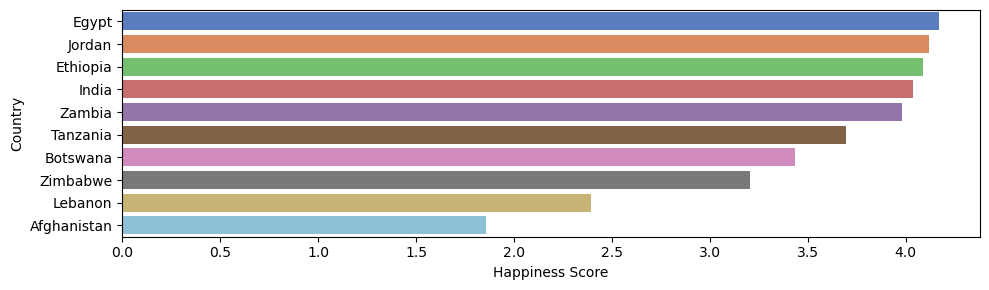

In [22]:
#Bar Plot showing the happiness score for all countries 
f, ax = plt.subplots(figsize=(10, 3))

#Gather the lowest 10 countries from this data
lowest_ten = completeDf.nsmallest(n = 10, columns = 'Happiness Score').sort_values(ascending = False, by = 'Happiness Score')

sns.barplot(
    data = lowest_ten,
    x = "Happiness Score", 
    y = "Country", 
    legend = False,
    palette = 'muted',
)

plt.tight_layout()
plt.show()


It is easy to see how the Middle East plays a significant portion of this plot with Egypt, Jordan, Lebanon, and Afghanistan all taking different spots. Much of the South African region also dominates with Zimbabwe, Botswana, Zambia, and Tanzania. Finally, India and Ethiopia both serve as the main outliers of the graph since neither are from the aforementioned regions 

The biggest aspect worth mentioning is the dramatic drop between the bottom five nations. For most of the data we've seen so far, many of the nations share very similar numbers, often only differing by very little. However, after Zambia, the nations differ by up to 0.4 in the happiness score. This makes me question if these nations are affected by the most influential parts that make a country unhappy, which makes sense considering the war-torn Afghanistan is sitting at the bottom.  

The most surprising parts about this plot to me were the African countries mentioned above. While nations such as Tanzania and Botswana aren't perfect, they still tend to have a much better quality of life in comparison to other countries. From this judgement alone, I assume that there are other poor factors about these nations that I do not know about yet. 

<Axes: xlabel='Happiness Score', ylabel='Count'>

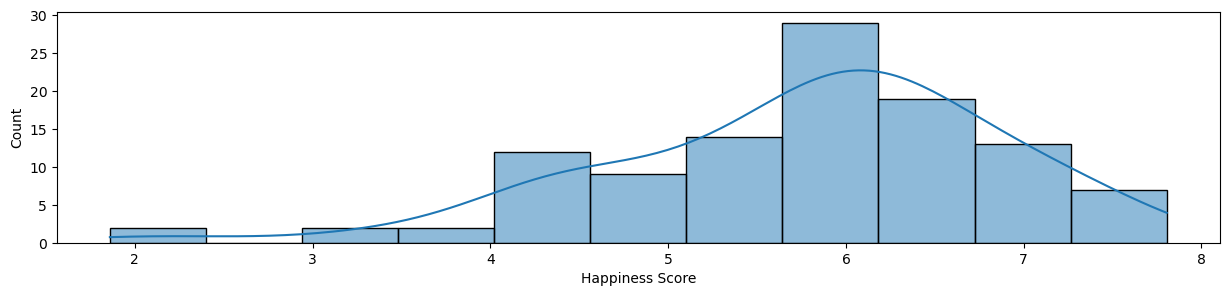

In [23]:
#Happiness KDE/histogram distribution 
f, ax = plt.subplots(figsize = (15, 3))
 
sns.histplot(
    data = completeDf, 
    x = 'Happiness Score',
    kde = True,
    bins = math.ceil(math.sqrt(completeDf.shape[0])) #Number of bins should be around the square root of total data points 
)

The overall distribution shows that a large portion of the nations have a happiness score ranging somewhere between 5 and 7. This is surprising considering that we never even reach a happiness score of 8 or higher. The best assumption that I have for this is that getting a perfect happiness score will be almost impossible. Even if a nation's conditions are perfect, many people will still be sad or depressed based on things happening in their personal life, such as the death of a family member. 

The only real outlier here is the country with a happiness score of about 2. From the last graph, we can see that that bar is most likely Afghanistan, therefore making it the strongest outlier in terms of happiness score alone.

### Healthcare Analysis

As previously mentioned, the healthcare portion of the data will include the following columns: Physicians Per Thousand Citizens, Out of Pocket Health Expenditure (%), and CO2-Emissions. This is mainly because many of these have to do with a nation's overall healthcare system, how accessible it is, and how pollution could play a role in the health of average citizens.

#### Top 5 Countries From Each Healthcare Column

/var/folders/9t/smb8cb7j223dk4xdg983zqmw0000gn/T/ipykernel_7293/1018571363.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  a.set_xticklabels(a.get_xticklabels(), rotation = 90, ha="right")
/var/folders/9t/smb8cb7j223dk4xdg983zqmw0000gn/T/ipykernel_7293/1018571363.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  a.set_xticklabels(a.get_xticklabels(), rotation = 90, ha="right")
/var/folders/9t/smb8cb7j223dk4xdg983zqmw0000gn/T/ipykernel_7293/1018571363.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  a.set_xticklabels(a.get_xticklabels(), rotation = 90, ha="right")


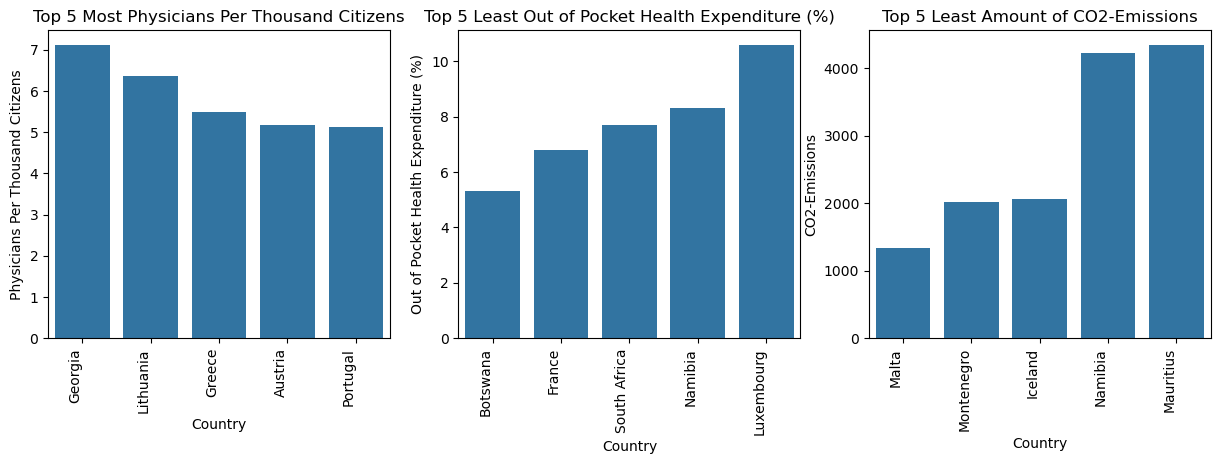

In [24]:
#Top 10 countries from each category
f, ax = plt.subplots(1, 3, figsize = (15, 4))

#Top 5 countries with most physicians 
top_five_physicians = completeDf.nlargest(n = 5, columns = 'Physicians Per Thousand Citizens').sort_values(ascending = False, by = 'Physicians Per Thousand Citizens')
sns.barplot(data = top_five_physicians, x = 'Country', y = 'Physicians Per Thousand Citizens', orient = 'v', ax = ax[0])
ax[0].set_title('Top 5 Most Physicians Per Thousand Citizens')

#Top 5 countries with least amount of Out of Pocket Health Expenditure (%)
bottom_five_health_expenditure = completeDf.nsmallest(n = 5, columns = 'Out of Pocket Health Expenditure (%)').sort_values(ascending = True, by = 'Out of Pocket Health Expenditure (%)')
sns.barplot(data = bottom_five_health_expenditure, x = 'Country', y = 'Out of Pocket Health Expenditure (%)', orient = 'v', ax = ax[1])
ax[1].set_title('Top 5 Least Out of Pocket Health Expenditure (%)')

#Top 5 countries with least amount of CO2-Emissions
bottom_five_cO2_emissions = completeDf.nsmallest(n = 5, columns = 'CO2-Emissions').sort_values(ascending = True, by = 'CO2-Emissions')
sns.barplot(data = bottom_five_cO2_emissions, x = 'Country', y = 'CO2-Emissions', orient = 'v', ax = ax[2])
ax[2].set_title('Top 5 Least Amount of CO2-Emissions')

for a in ax:
    a.set_xticklabels(a.get_xticklabels(), rotation = 90, ha="right")

From the above, it is easy to see a trend in the data. For instance, in all three columns, Europe absolutely dominates with  small amount of African countries as well. 

The first graph shows every spot taken by a European country, more specifically, Eastern Europe. Georgia took the top spot with approximately 7 physicians for every thousand citizen. This seems to be a minor outlier considering that Austria and Portugal, countries in the fourth and fifth positions, only have around 5. However, it's also worth mentioning that Austria and Portugal have around three times the population as Georgia, so achieving these levels of healthcare is a lot harder for these countries. 

The health expenditure was most surprising. To start off, there was a huge concentration of the South African region with Botswana, South Africa, and Namibia all taking spots. In addition, none of the percentages seen here were close to each other at all, with all of them differing to about 1% each. The important thing to note is the size and population of these nations. With Luxembourg's size and economy, achieving this wouldn't be hard since there isn't a huge population to begin with. The same could be said about Botswana and Namibia, both countries with populations around 3 million people in total.

This same pattern could be seen in the carbon emissions graph, with smaller nations such as Malta, Montenegro, and Mauritius all taking spots. Namibia once again takes a spot which should be praised upon, given it's overall size and wildlife found in the nation. 

With these graphs in mind, we can already see patterns of how European, smaller nations will tend to do better thanks to their smaller population. 


#### Healthcare Distribution 

Text(0.5, 1.0, 'CO2-Emissions Distributions')

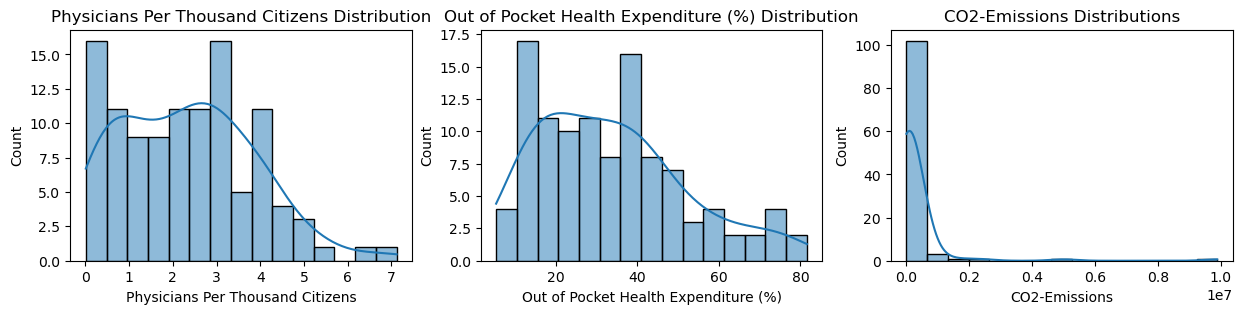

In [25]:
#Happiness KDE distribution 
f, ax = plt.subplots(1, 3, figsize = (15, 3))
 
sns.histplot(data = completeDf, x = 'Physicians Per Thousand Citizens', kde = True, bins = 15, ax = ax[0])
ax[0].set_title('Physicians Per Thousand Citizens Distribution')

sns.histplot(data = completeDf, x = 'Out of Pocket Health Expenditure (%)', kde = True, bins = 15, ax = ax[1])
ax[1].set_title('Out of Pocket Health Expenditure (%) Distribution')

sns.histplot(data = completeDf, x = 'CO2-Emissions', kde = True, bins = 15, ax = ax[2])
ax[2].set_title('CO2-Emissions Distributions')

The distributions of each graph shows new patterns as well. Overall, it seems that most nations tend to have approximately 1 or 3 physicians for every thousand citizens. This can be seen through the two peaks in the KDE seen in the graph. The only outliers are the few countries that have slightly above 6 physicians, which based on what we already know, is most likely the few countries discussed in the previous section.

The out of pocket health expenditure is the most balanced distribution between all three options. The most amount of data lies between approximately 20-40% based on the peaks in the graph. There are also no explicit outliers in the graph either, the closest one being the small amount of countries that reach the 70-80% range. 

The CO2-Emissions graph is by far the most skewed distribution with a very harsh right distribution. Nearly every single nation gets to a very minimal amount of emissions with few nations acting as outliers with very large amounts of emissions in comparison. 

#### Healthcare vs. Happiness Correlation

Text(0.5, 1.0, 'CO2 Emissions vs. Happiness Correlation')

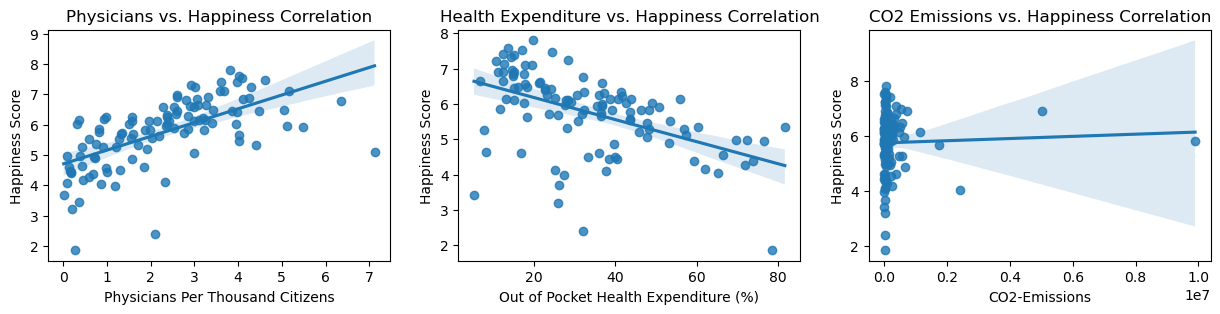

In [26]:
f, ax = plt.subplots(1, 3, figsize = (15, 3))

#Correlation between them 
sns.regplot(data = completeDf, x = 'Physicians Per Thousand Citizens', y = 'Happiness Score', ax = ax[0])
ax[0].set_title('Physicians vs. Happiness Correlation')

sns.regplot(data = completeDf, x = 'Out of Pocket Health Expenditure (%)', y = 'Happiness Score', ax = ax[1])
ax[1].set_title('Health Expenditure vs. Happiness Correlation')

sns.regplot(data = completeDf, x = 'CO2-Emissions', y = 'Happiness Score', ax = ax[2])
ax[2].set_title('CO2 Emissions vs. Happiness Correlation')

Based upon first impressions, the graphs above make a lot of sense. While many of them do not have very distinct patterns based on the points, I was still able to get a decent function. 

The physicians graph has the steepest line, which makes sense since many citizens would feel more comfortable if there were more medical professionals at their disposal in case they ever get hurt or sick. 

On the other hand, the health expenditure graph has a fairly steep downward trend, something that is also supported based on the points shown. 

The only odd graph here is the carbon emissions graph, showing how the slope is almost a horizontal line with a slight upward trend. Considering what we saw in the distribution for this data, this makes sense considering that there was almost no variability amongst the nations, hence showing that most people are indifferent when it comes to pollution. The positive trend could also be influenced by the few outliers we saw. 

### Citizen Safety Analysis

#### Top 5 Best Countries in Each Citizen Safety Column

/var/folders/9t/smb8cb7j223dk4xdg983zqmw0000gn/T/ipykernel_7293/1982780531.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  a.set_xticklabels(a.get_xticklabels(), rotation = 90, ha="right")
/var/folders/9t/smb8cb7j223dk4xdg983zqmw0000gn/T/ipykernel_7293/1982780531.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  a.set_xticklabels(a.get_xticklabels(), rotation = 90, ha="right")
/var/folders/9t/smb8cb7j223dk4xdg983zqmw0000gn/T/ipykernel_7293/1982780531.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  a.set_xticklabels(a.get_xticklabels(), rotation = 90, ha="right")


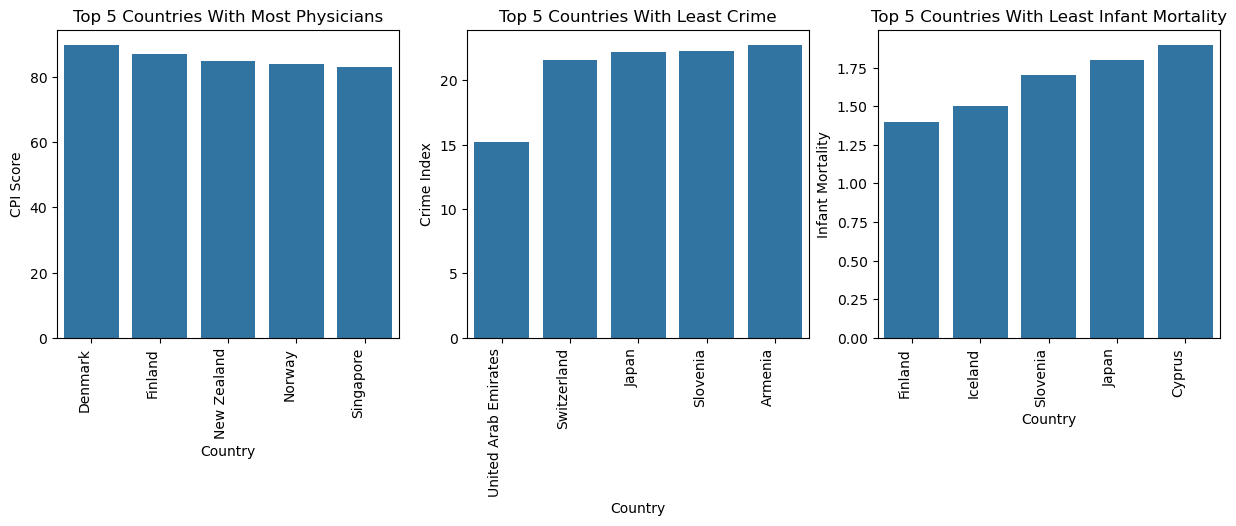

In [60]:
#Top 5 countries from each column
f, ax = plt.subplots(1, 3, figsize = (15, 4))

#Top 5 countries with most physicians 
top_five_CPI = completeDf.nlargest(n = 5, columns = 'CPI Score').sort_values(ascending = False, by = 'CPI Score')
sns.barplot(data = top_five_CPI, x = 'Country', y = 'CPI Score', orient = 'v', ax = ax[0])
ax[0].set_title("Top 5 Countries With Most Physicians")

#Top 5 Countries With Least Crime
bottom_five_crime = completeDf.nsmallest(n = 5, columns = 'Crime Index').sort_values(ascending = True, by = 'Crime Index')
sns.barplot(data = bottom_five_crime, x = 'Country', y = 'Crime Index', orient = 'v', ax = ax[1])
ax[1].set_title("Top 5 Countries With Least Crime")

#Top 5 Countries With Infant Mortality
bottom_five_infant_mortality = completeDf.nsmallest(n = 5, columns = 'Infant Mortality').sort_values(ascending = True, by = 'Infant Mortality')
sns.barplot(data = bottom_five_infant_mortality, x = 'Country', y = 'Infant Mortality', orient = 'v', ax = ax[2])
ax[2].set_title("Top 5 Countries With Least Infant Mortality")



for a in ax:
    a.set_xticklabels(a.get_xticklabels(), rotation = 90, ha="right")

The bars above show very similar patterns to those in the previous category. Each category seems to be dominated by Europe with a heavier emphasis on the western part of the continent. 

The CPI score shows that amongst the higher countries, there seems to not be such a drastic difference. This very easily could be because of the arbitrary scale made to rank each country, and since it only includes whole numbers from 1-100, there wouldn't be much room to be more specific. Alongside this, most of the countries here are from the Scandinavian region with Denmark, Finland, and Norway all taking spots. What's worth mentioning is that countries with the highest happiness rates were all Scandinavian as well, indicating that a CPI Score could play a major role in a population's happiness. 

The regions in the lowest crime index bar plot show to be more variable, with the UAE taking the top spot alongside nations such as Switzerland and Japan. Aside from the UAE, there seems to not be a huge difference in crime index in the top positions.

Finally, infant mortality's lowest two countries were both again, Scandinavian. Since Finland and Iceland were both in the top three happiness countries on Earth, this might be a contender for being one of the most influential factors here.

#### Distribution of Each Factor in the Citizen Safety Column

<Axes: xlabel='Infant Mortality', ylabel='Count'>

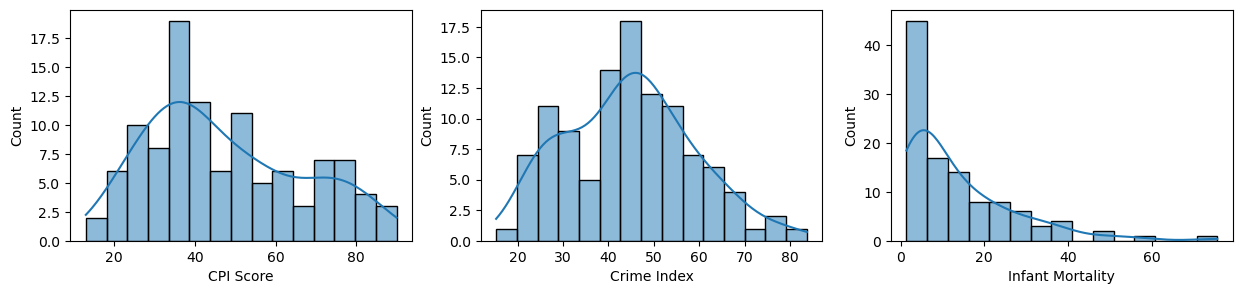

In [28]:
f, ax = plt.subplots(1, 3, figsize = (15, 3))
 
sns.histplot(data = completeDf, x = 'CPI Score', kde = True, bins = 15, ax = ax[0])
sns.histplot(data = completeDf, x = 'Crime Index', kde = True, bins = 15, ax = ax[1])
sns.histplot(data = completeDf, x = 'Infant Mortality', kde = True, bins = 15, ax = ax[2])

The CPI score overall distribution seems fairly normal with a slight right skew. The data doesn't seem to go past around 93, which makes sense considering that achieving a perfect score in this category would be very difficult. While there are no clear outliers, it seems that many of the countries lie slightly below 40. 

The crime index distribution has a fairly normal distribution except for the second peak at around 30. A large portion of the countries lie between 40 and 50. The only real outliers would be the single nation with a below 20 crime index score, however, there is no good reason to get rid of this nation, so it's best to keep it. 

Finally, the infant mortality distribution has a harsh right distribution with over 40 countries having a very low infant mortality rate. The only outlier is the only nation with above a 60% rate. 

#### Citizen Safety vs. Happiness Correlation

<Axes: xlabel='Infant Mortality', ylabel='Happiness Score'>

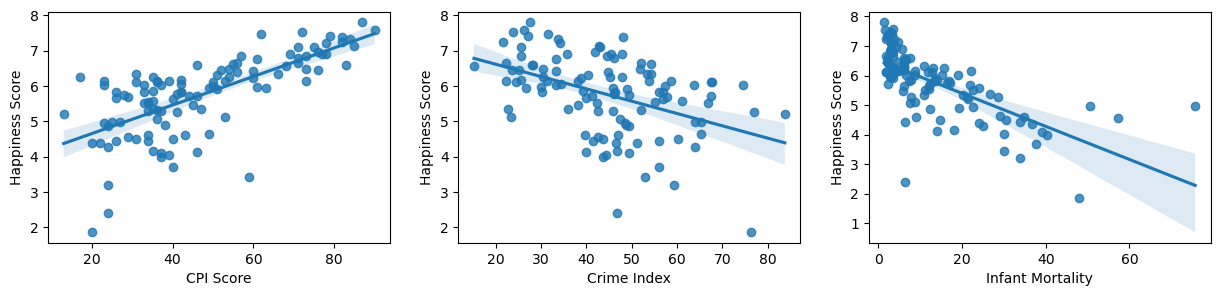

In [29]:
f, ax = plt.subplots(1, 3, figsize = (15, 3))

#Correlation between them 
sns.regplot(data = completeDf, x = 'CPI Score', y = 'Happiness Score', ax = ax[0])
sns.regplot(data = completeDf, x = 'Crime Index', y = 'Happiness Score', ax = ax[1])
sns.regplot(data = completeDf, x = 'Infant Mortality', y = 'Happiness Score', ax = ax[2])

The correlations between these factors and the happiness scores are very interesting and much more clear in comparison to the previous section. 

The CPI score has a very steep positive slope, indicating that the country's corruption has a very strong influence on happiness. However, the complete opposite could be said about the crime index and infant mortality, since both of them have the steepest, negative slopes we've seen up to this point. It would be no surprise to me if either of these had the most influence on the happiness of a nation. 

### Economy Analysis

#### Top 5 Best Countries in Each Economy Column

/var/folders/9t/smb8cb7j223dk4xdg983zqmw0000gn/T/ipykernel_7293/582040271.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  a.set_xticklabels(a.get_xticklabels(), rotation = 90, ha="right")
/var/folders/9t/smb8cb7j223dk4xdg983zqmw0000gn/T/ipykernel_7293/582040271.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  a.set_xticklabels(a.get_xticklabels(), rotation = 90, ha="right")


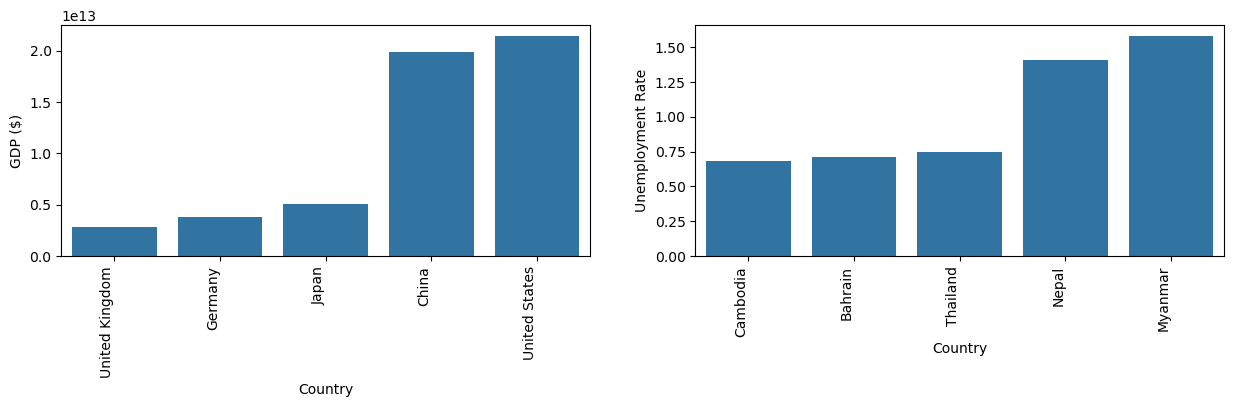

In [ ]:
#Top 10 countries from each category

f, ax = plt.subplots(1, 2, figsize = (15, 3))

#Top 5 countries with most physicians 
top_five_economies = completeDf.nlargest(n = 5, columns = 'GDP ($)').sort_values(ascending = True, by = 'GDP ($)')
sns.barplot(data = top_five_economies, x = 'Country', y = 'GDP ($)', orient = 'v', ax = ax[0])

#Top 5 countries with least amount of Out of Pocket Health Expenditure (%)
bottom_five_unemployment = completeDf.nsmallest(n = 5, columns = 'Unemployment Rate').sort_values(ascending = True, by = 'Unemployment Rate')
sns.barplot(data = bottom_five_unemployment, x = 'Country', y = 'Unemployment Rate', orient = 'v', ax = ax[1])

for a in ax:
    a.set_xticklabels(a.get_xticklabels(), rotation = 90, ha="right")


A lot of the top nations here are countries that you would expect to see. It was no secret that the US and China both have the strongest economies in the world. What is surprising is the unemployment rates. Southeast Asia dominates with Thailand, Cambodia, and Myanmar all taking spots. None of these countries have been seen before when observing happiness by itself, so it's safe to say that this factor may not have a huge influence on happiness. 

#### Distribution of Each Factor in the Economy Column

<Axes: xlabel='Unemployment Rate', ylabel='Count'>

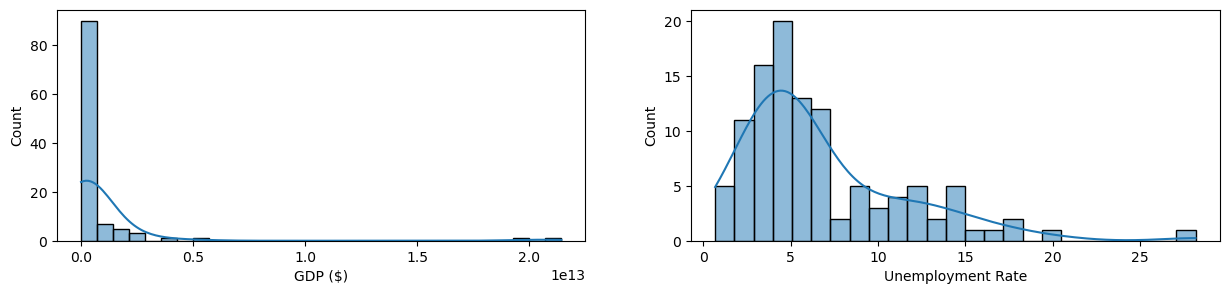

In [31]:
f, ax = plt.subplots(1, 2, figsize = (15, 3))
 
sns.histplot(data = completeDf, x = 'GDP ($)', kde = True, bins = 30, ax = ax[0])
sns.histplot(data = completeDf, x = 'Unemployment Rate', kde = True, bins = 25, ax = ax[1])

Both distributions have a very strong right skew, with many countries having very low GDPs and low unemployment rates. While there are few outliers seen in both graphs, there is no clear reason to get rid of them since they are not errors or bad data, so they will be kept.

#### Economy vs. Happiness Correlation

<Axes: xlabel='Unemployment Rate', ylabel='Happiness Score'>

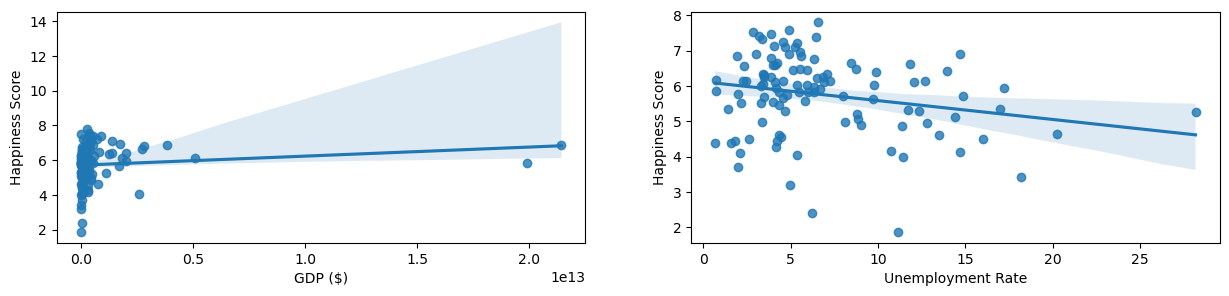

In [32]:
f, ax = plt.subplots(1, 2, figsize = (15, 3))

#Correlation between them 

sns.regplot(data = completeDf, x = 'GDP ($)', y = 'Happiness Score', ax = ax[0])
sns.regplot(data = completeDf, x = 'Unemployment Rate', y = 'Happiness Score', ax = ax[1])

As predicted in the bar plots for this category, neither have a very strong correlation with happiness. The correlation between GDP and happiness is almost a straight line while the correlation with unemployment rate has a very subtle negative correlation. 

### Numeric Correlations

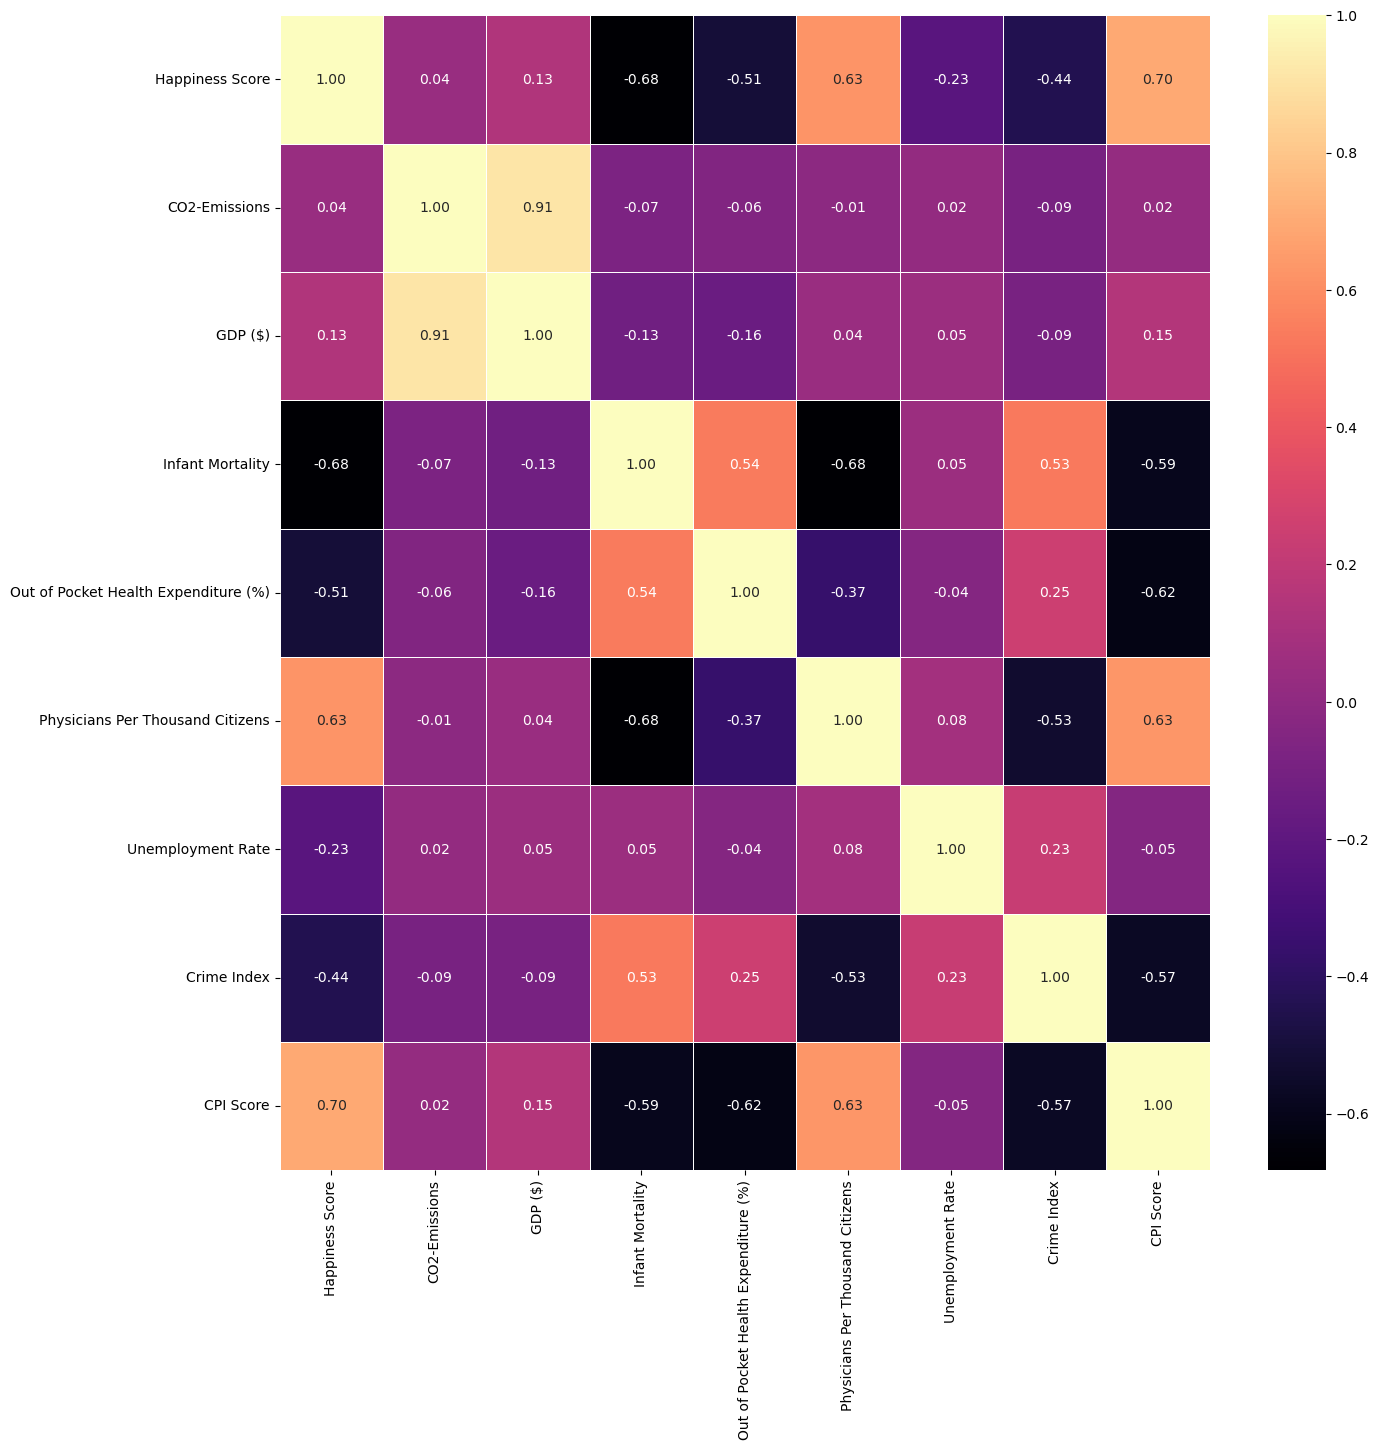

In [33]:
#Set the size of the correlation matrix 
f, ax = plt.subplots(figsize=(15, 15))

#Set up and calculate the correlation (eliminate other columns, this study only focuses on happiness)
heatmap_df = completeDf.drop(columns = 'Country')
correlation_matrix = heatmap_df.corr()

#Display heatmap 
sns.heatmap(
    correlation_matrix, 
    annot = True, 
    cmap = "magma", 
    fmt = ".2f", 
    linewidths = 0.5
)

plt.show()

The above heat map shows the same correlations we saw before, but in numerical form. Based on this alone, it is evident that the strongest, positive correlation with happiness is the CPI score with a 0.70. This therefore indicates that the less corrupt a nation is, the happier people will be. While this may be obvious in theory, it shows that it will certainly have a significant influence on happiness inside a country. Judging from this alone, we can confidently say that this may be true with other political factors as well.

On the other hand, infant mortality has the strongest negative correlation with a -0.68 correlation, showing its significant impact on happiness. With this information, we can make an assumption that mortality in general can have a huge negative correlation with happiness since it can affect an entire family and friend simultaneously, especially if its infant mortality. 

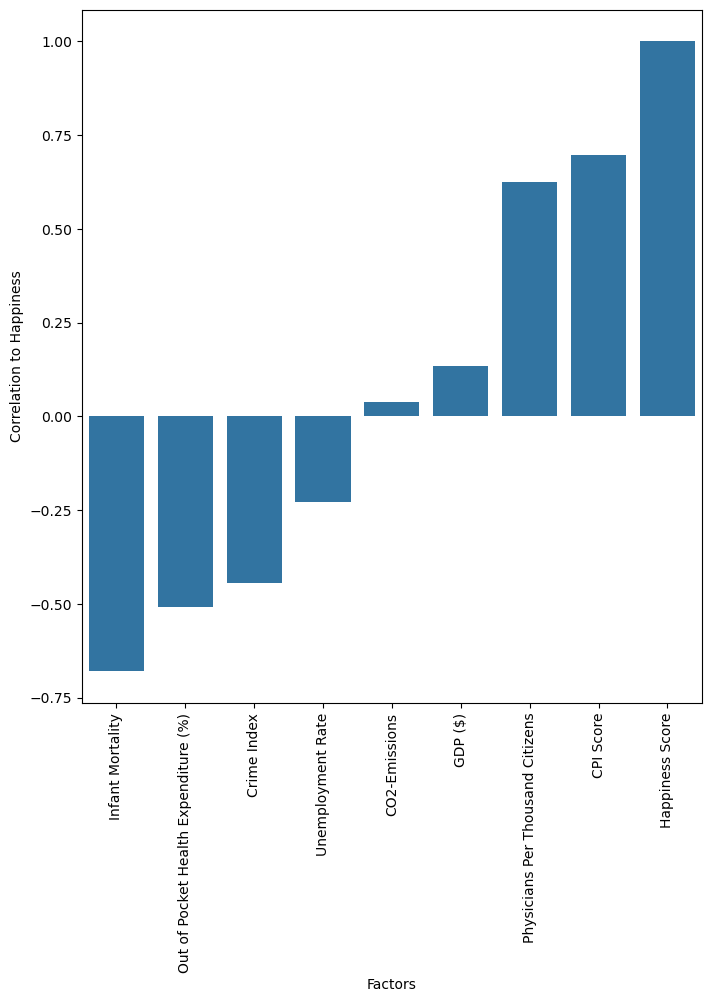

In [34]:
#Barplot with the happiness row 
f, ax = plt.subplots(figsize=(8, 9))

correlation_matrix_bar = correlation_matrix['Happiness Score'].sort_values(ascending = True)

sns.barplot(
    data = correlation_matrix_bar
)

#Turn the title of the bar titles vertically
plt.xticks(rotation=90)

#Rename axes
ax.set_ylabel('Correlation to Happiness')
ax.set_xlabel('Factors')

#Show plot 
plt.show()


The bar plot above visually displays the same data from the correlation matrix. 

# Clustering and Analysis

The following section will entail various predictions about the happiness of a country, including what the most influential factor for happiness is and analyzing using k-means clustering.

Incorporating machine learning algorithms such as these was a vital decision, mainly because k-means clustering allows us to see patterns that I wouldn't have been able to recognize otherwise. It's also important because it allows us to narrow down the data into groups of countries and similar traits and determine the happiness of each group. For instance, if a group has a poor economy and low happiness rate, then that may say how much influence the economy has on a population's mental health. 

To achieve this, we will need to perform k-means for every category, discover the patterns within those groups, and then analyze how the happiness scores compare between them. For consistently, we will forms groups of 4 clusters for each category.

In [35]:
#Review of what the completeDf dataframe looks like
completeDf.head()

,Country,Happiness Score,CO2-Emissions,GDP ($),Infant Mortality,Out of Pocket Health Expenditure (%),Physicians Per Thousand Citizens,Unemployment Rate,Crime Index,CPI Score
0,Afghanistan,1.8590,8672,1.910135e+10,47.9,78.4,0.28,11.12,76.31,20
1,Albania,5.2773,4536,1.527808e+10,7.8,56.9,1.20,12.33,42.53,37
2,Algeria,5.3291,150006,1.699882e+11,20.1,28.1,1.72,11.70,52.03,36
3,Argentina,6.0237,201348,4.496634e+11,8.8,17.6,3.96,9.79,63.82,37
4,Armenia,5.3417,5156,1.367280e+10,11.0,81.6,4.40,16.99,22.79,47


## K-Means Clustering

### Health Care K-Means Clustering

In [36]:
#Tools needed for the K-Means Clustering techniques
k_means_model = KMeans(n_clusters = 4, random_state = 42)
scaler = StandardScaler()

In [37]:
#Scale down the data for proper analysis 
scaled_health_data = scaler.fit_transform(completeDf[['Physicians Per Thousand Citizens', 'Out of Pocket Health Expenditure (%)', 'CO2-Emissions']])

#Predict 
health_pred = k_means_model.fit_predict(scaled_health_data)
health_pred

array([3, 3, 1, 0, 3, 0, 0, 1, 3, 0, 1, 1, 1, 0, 3, 3, 0, 1, 2, 1, 0, 0,
       1, 0, 0, 1, 1, 3, 1, 0, 1, 0, 0, 0, 0, 1, 0, 3, 3, 0, 0, 3, 3, 1,
       3, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 3,
       3, 1, 3, 0, 0, 1, 3, 0, 3, 1, 1, 1, 3, 1, 0, 0, 0, 0, 1, 1, 0, 0,
       1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 2, 0, 1, 1, 1, 1, 1],
      dtype=int32)

In [38]:
#Make sure that we have the health cluster present in the data
completeDf['Health Cluster'] = health_pred
completeDf.head()

,Country,Happiness Score,CO2-Emissions,GDP ($),Infant Mortality,Out of Pocket Health Expenditure (%),Physicians Per Thousand Citizens,Unemployment Rate,Crime Index,CPI Score,Health Cluster
0,Afghanistan,1.8590,8672,1.910135e+10,47.9,78.4,0.28,11.12,76.31,20,3
1,Albania,5.2773,4536,1.527808e+10,7.8,56.9,1.20,12.33,42.53,37,3
2,Algeria,5.3291,150006,1.699882e+11,20.1,28.1,1.72,11.70,52.03,36,1
3,Argentina,6.0237,201348,4.496634e+11,8.8,17.6,3.96,9.79,63.82,37,0
4,Armenia,5.3417,5156,1.367280e+10,11.0,81.6,4.40,16.99,22.79,47,3


current cluster 0: (40, 11)
current cluster 1: (49, 11)
current cluster 2: (2, 11)
current cluster 3: (18, 11)


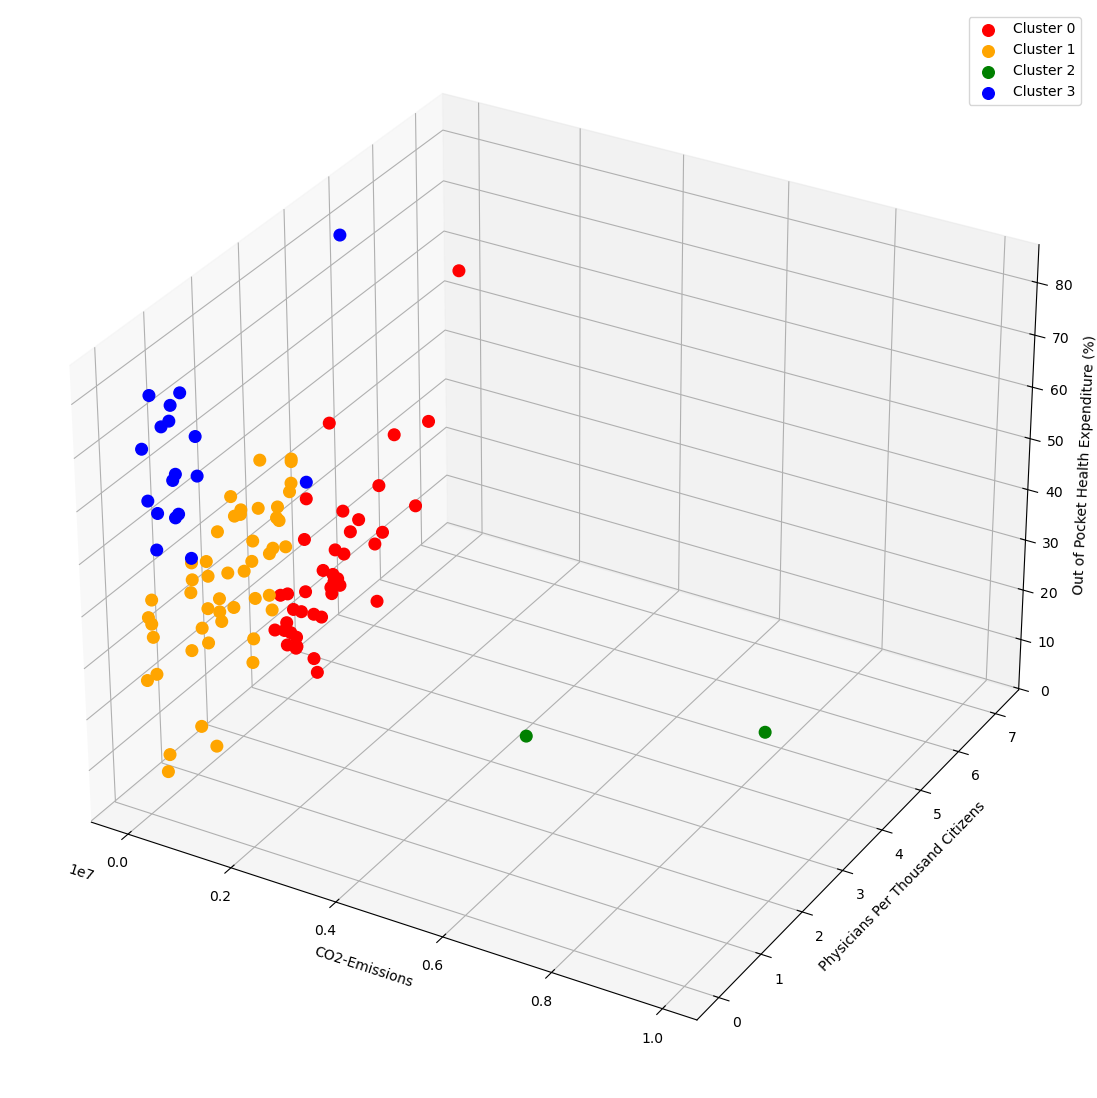

In [39]:
#Fix the size of the overall projections 
fig = plt.figure(figsize = (14, 14))
ax = fig.add_subplot(projection='3d')

#Create a list of colors for each color 
colors_list = ['red', 'orange', 'green', 'blue', 'purple']


scaler = StandardScaler()

#Loop that displays each color 
for i in range (0, 4, 1): 
    current_cluster = completeDf[completeDf['Health Cluster'] == i]

    ax.scatter(
        xs = current_cluster['CO2-Emissions'],
        ys = current_cluster['Physicians Per Thousand Citizens'],
        zs = current_cluster['Out of Pocket Health Expenditure (%)'], 
        color = colors_list[i],
        label = f'Cluster {i}',
        s = 70,
        alpha = 1
    )

    print(f'current cluster {i}:', current_cluster.shape)


#Scale the x axis for more visibility


#Set axes labels and show legend
ax.set_xlabel('CO2-Emissions')
ax.set_ylabel('Physicians Per Thousand Citizens')
ax.set_zlabel('Out of Pocket Health Expenditure (%)')
ax.legend()

The patterns we see based on the 3D scatter plot alone show a variety of different patterns: 

- Cluster 0 (red): countries with many physicians, somewhat little health expenditure, and almost no carbon emissions
- Cluster 1 (orange): countries with little to no emissions, high out of pocket health expenditure, and few physicians 
- Cluster 2 (green): blatant outliers that don't seem to fit with any of the other three groups. They seem to have high carbon emissions 
- Cluster 3 (blue): countries with few carbon emissions and physicians, but a very high out of pocket health expenditure

#### Health Cluster Analysis by Variable 

In [40]:
#Function that creates various histograms for each cluster and its respective variables. 



#Javadoc??...
def cluster_hist_graph(cluster, var_list, colors_list, bins_num, kde_bool, length, width, x_graphs, y_graphs):
   
    f, ax = plt.subplots(y_graphs, x_graphs, figsize = (length, width))
    ax = np.ravel(ax)

    for a in range (0, len(ax), 1): 
        sns.histplot(
            data = completeDf[completeDf[cluster] == math.floor(a / x_graphs)], 
            x = var_list[a % len(var_list)], 
            color = colors_list[math.floor(a / x_graphs)],
            kde = kde_bool, 
            bins = bins_num, 
            ax = ax[a]
        ) 

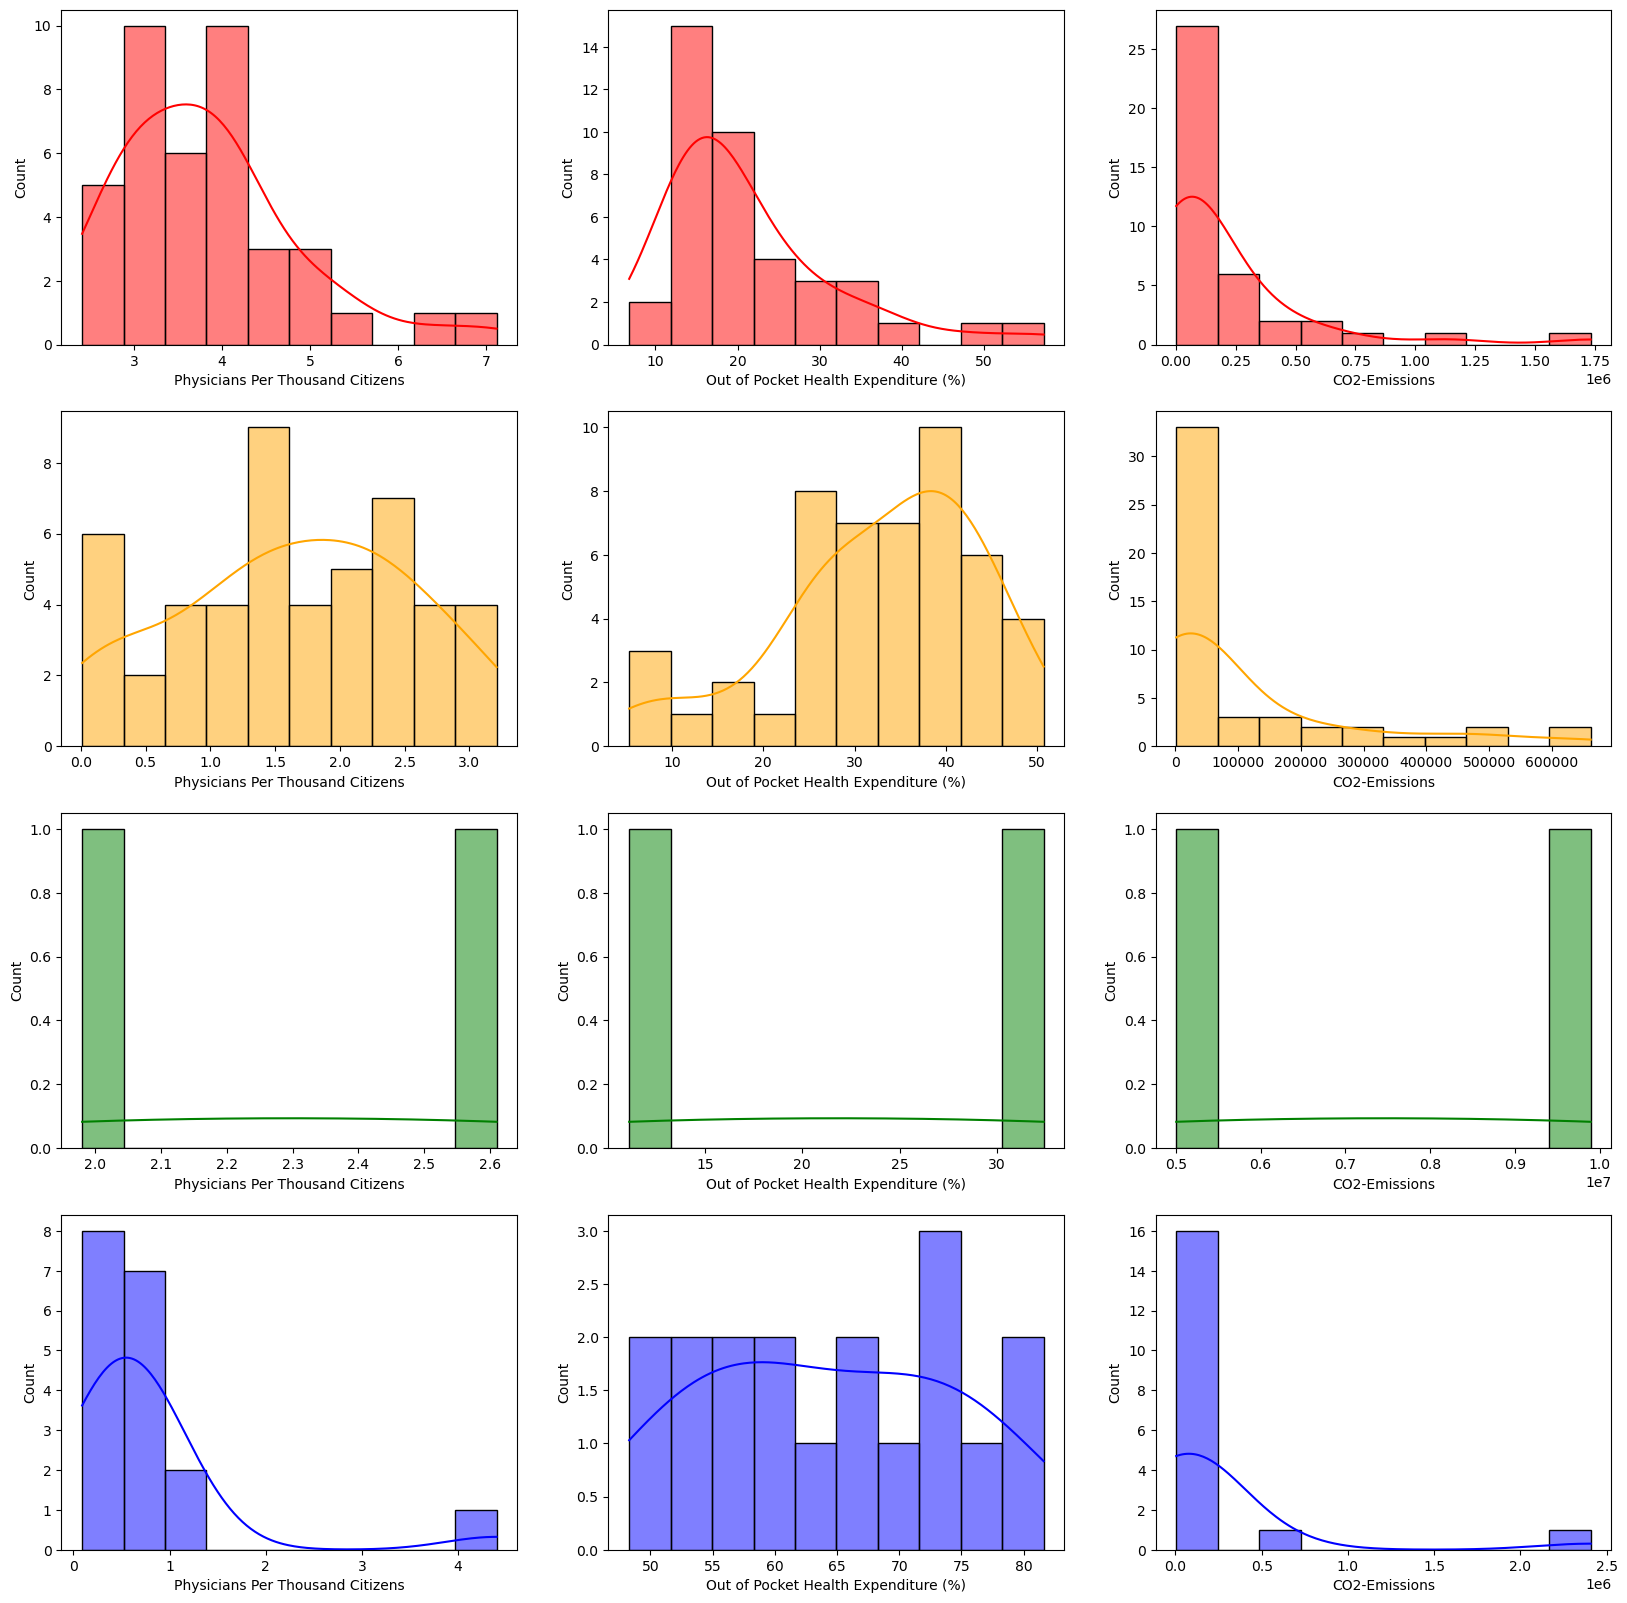

In [41]:
cluster_hist_graph(
    cluster = 'Health Cluster', 
    var_list = ['Physicians Per Thousand Citizens', 'Out of Pocket Health Expenditure (%)', 'CO2-Emissions'], 
    colors_list = ['red', 'orange', 'green', 'blue'], 
    bins_num = 10, 
    kde_bool = True, 
    length = 20,
    width = 20, 
    x_graphs = 3, 
    y_graphs = 4,
)


The overall analysis from the scatter plot seems to be very supported by these histograms, here are some details worth mentioning: 

- Cluster 2 (green) has virtually no countries within it, therefore explaining why all of its histograms are not very descriptive. We can therefore assume that this is just made up of the two outliers we saw in the scatter plot and nothing else.
- Carbon emissions across the clusters have almost no diversity since the spreads look mostly the same. This makes sense considering that the overall carbon emission histogram for all countries had the harshest right skew out of all the data we saw, so we really shouldn't expect it to differ farther than that. However, cluster 0 (red) has the most variability since its overall spread goes out way farther than the other clusters. Again, this isn't anything revolutionary considering the other histograms. 
- Cluster 0 (red) seems to have the most amount of physicians with most of the nations, with the the peak in the KDE being at around 3.5. Even though they have far less countries in the cluster, cluster 3 (blue) has the least amount of physicians with a hard right skew peaking at around 0.5. 
- Cluster 2 (blue) has the most expensive healthcare with the health expenditure ranging from 50-80% with no significant peaks. On the contrary, cluster 0 (red) has the cheapest with a harsh right skew peaking at around 16-17%. 

#### Health Cluster Happiness Analysis

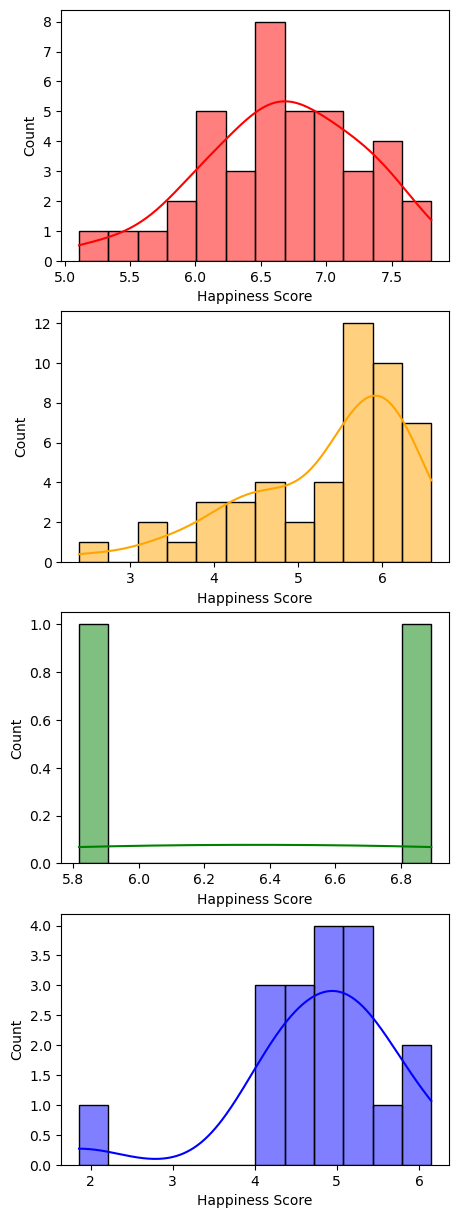

In [42]:
cluster_hist_graph(
    cluster = 'Health Cluster', 
    var_list = ['Happiness Score'], 
    colors_list = ['red', 'orange', 'green', 'blue'],  
    bins_num = 12, 
    kde_bool = True, 
    length = 5,
    width = 15, 
    x_graphs = 1, 
    y_graphs = 4,
)

Judging from the distributions above, we can easily see that cluster 0 is by far the happiest cluster, with a peak of around 6.7 of happiness and the distribution ranging from 5.1 to around 7.9. Based on what we know from the previous section, cluster 0 had the highest overall number of physicians and cheapest health care, showing that both of these may have strong impacts and overall improve happiness amongst citizens.

The same could be said about clusters 1 and 3, both of which perform worse. The detail worth noticing is that even though cluster 3 has the worst numbers overall, the difference between that and cluster 1 isn't very large since their peaks both differ by about 1 on the happiness scale. This shows that even though it does have an impact, it may not be the strongest factor here. 

Since cluster 2 only contains outliers, we unfortunately cannot pull much information about it since it wouldn't create a fair comparison with the other clusters.

#### Health Cluster Average Happiness

In [43]:
#Catgorical Data 

def average_happiness_plot(cluster_names, cluster_type, given_alpha, cluster_color_palette):
    
    #Error trap
    if len(cluster_color_palette) != len(cluster_names):
        print("Insert the same amount of colors and cluster names")
        return 

        
    average_scores_list = [completeDf[completeDf[cluster_type] == a]['Happiness Score'].mean() for a in range (len(cluster_names))]


    dataDf = pd.DataFrame({
        'Clusters' : cluster_names,
        'Average Happiness Score' : average_scores_list, 
    })

    sns.barplot(
        data = dataDf, 
        x = 'Clusters',
        y = 'Average Happiness Score',
        palette = cluster_color_palette,
        alpha = given_alpha  
    )

/var/folders/9t/smb8cb7j223dk4xdg983zqmw0000gn/T/ipykernel_7293/557943936.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


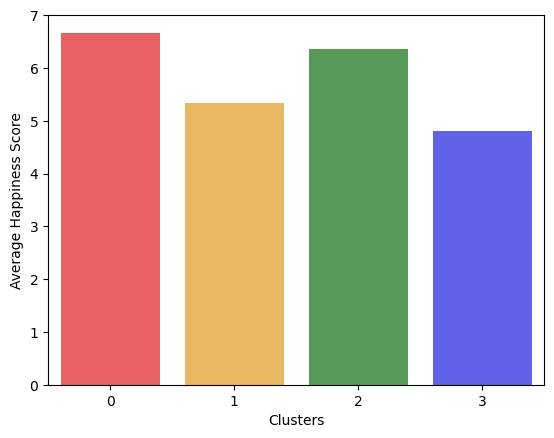

In [44]:
average_happiness_plot(
    cluster_names = ['0', '1', '2', '3'],
    cluster_type = 'Health Cluster', 
    given_alpha = 0.7, 
    cluster_color_palette = ['red', 'orange', 'green', 'blue']
)

Cluster 0 is shown overall to have the highest average happiness, differing a lot from clusters 1 and 3. This makes sense considering that it had the best numbers out of all the clusters as seen in the histograms for each column. Once again, cluster 3 is the most unhappy cluster, but not by the huge margin we'd expect given its poor conditions.

### Citizen Safety K-Means Clustering

In [45]:
scaled_safety_data = scaler.fit_transform(completeDf[['Infant Mortality', 'Crime Index', 'CPI Score']])

safety_pred = k_means_model.fit_predict(scaled_safety_data)
safety_pred

array([3, 1, 2, 2, 1, 0, 0, 1, 2, 0, 2, 2, 2, 1, 2, 3, 0, 0, 1, 2, 1, 0,
       0, 0, 0, 2, 2, 1, 2, 0, 3, 0, 0, 0, 0, 3, 1, 2, 2, 1, 0, 2, 2, 2,
       2, 0, 0, 1, 2, 0, 1, 1, 2, 2, 0, 1, 0, 0, 1, 1, 1, 2, 1, 2, 1, 2,
       3, 2, 1, 0, 0, 2, 3, 0, 3, 1, 2, 2, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0,
       2, 0, 0, 1, 0, 0, 3, 1, 1, 1, 3, 1, 0, 0, 0, 0, 1, 2, 1, 3, 3],
      dtype=int32)

In [46]:
completeDf['Safety Cluster'] = safety_pred
completeDf.head()

,Country,Happiness Score,CO2-Emissions,GDP ($),Infant Mortality,Out of Pocket Health Expenditure (%),Physicians Per Thousand Citizens,Unemployment Rate,Crime Index,CPI Score,Health Cluster,Safety Cluster
0,Afghanistan,1.8590,8672,1.910135e+10,47.9,78.4,0.28,11.12,76.31,20,3,3
1,Albania,5.2773,4536,1.527808e+10,7.8,56.9,1.20,12.33,42.53,37,3,1
2,Algeria,5.3291,150006,1.699882e+11,20.1,28.1,1.72,11.70,52.03,36,1,2
3,Argentina,6.0237,201348,4.496634e+11,8.8,17.6,3.96,9.79,63.82,37,0,2
4,Armenia,5.3417,5156,1.367280e+10,11.0,81.6,4.40,16.99,22.79,47,3,1


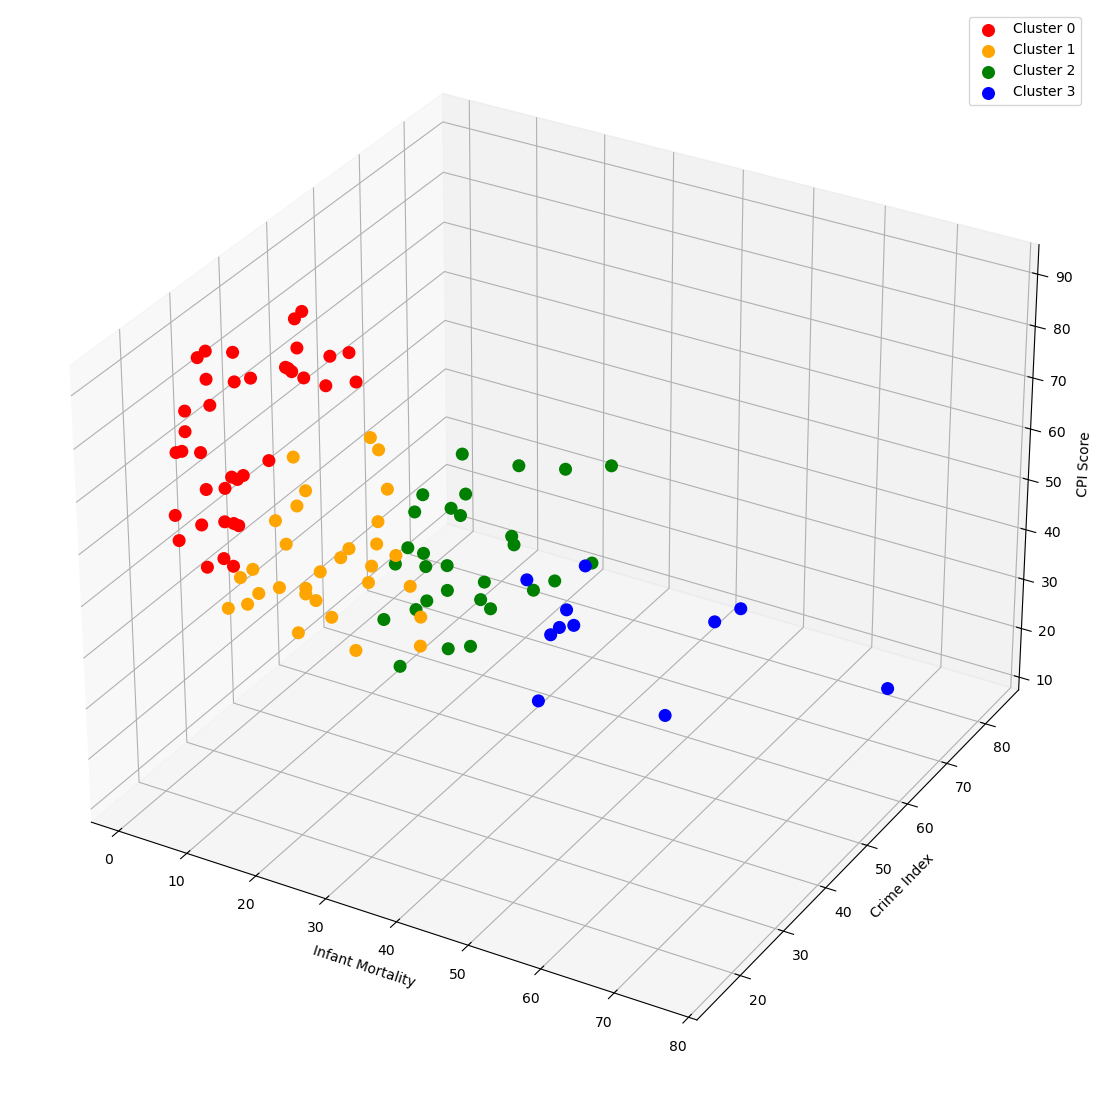

In [47]:
#Fix the size of the overall projections 
fig = plt.figure(figsize = (14, 14))
ax = fig.add_subplot(projection='3d')

#Create a list of colors for each color 
colors_list = ['red', 'orange', 'green', 'blue', 'purple']

#Loop that displays each color 
for i in range (0, 4, 1): 
    current_cluster = completeDf[completeDf['Safety Cluster'] == i]

    ax.scatter(
        xs = current_cluster['Infant Mortality'],
        ys = current_cluster['Crime Index'],
        zs = current_cluster['CPI Score'], 
        color = colors_list[i],
        label = f'Cluster {i}',
        s = 70,
        alpha=1,
    )

#Set axes labels and show legend
ax.set_xlabel('Infant Mortality')
ax.set_ylabel('Crime Index')
ax.set_zlabel('CPI Score')


plt.legend()



The clusters here are much more uniform and clear than the clusters for the quality of health care. Judging from this scatter plot alone, we can make the following judgments:

- Cluster 0 (red) has little to no infant mortality, scores high on the CPI scale, and has a somewhat low crime index in comparison to other clusters
- Cluster 1 (orange) has a slightly higher infant mortality, similar crime index, and scores a bit lower on the CPI scale in comparison to cluster 0
- Cluster 2 (green) has slightly worse conditions than the previous two clusters, but performs significantly worse on the CPI scale
- Cluster 3 (blue) has the worst numbers overall, with a high crime index, high infant mortality, and terribly low CPI scores 

In [48]:
completeDf.head()

,Country,Happiness Score,CO2-Emissions,GDP ($),Infant Mortality,Out of Pocket Health Expenditure (%),Physicians Per Thousand Citizens,Unemployment Rate,Crime Index,CPI Score,Health Cluster,Safety Cluster
0,Afghanistan,1.8590,8672,1.910135e+10,47.9,78.4,0.28,11.12,76.31,20,3,3
1,Albania,5.2773,4536,1.527808e+10,7.8,56.9,1.20,12.33,42.53,37,3,1
2,Algeria,5.3291,150006,1.699882e+11,20.1,28.1,1.72,11.70,52.03,36,1,2
3,Argentina,6.0237,201348,4.496634e+11,8.8,17.6,3.96,9.79,63.82,37,0,2
4,Armenia,5.3417,5156,1.367280e+10,11.0,81.6,4.40,16.99,22.79,47,3,1


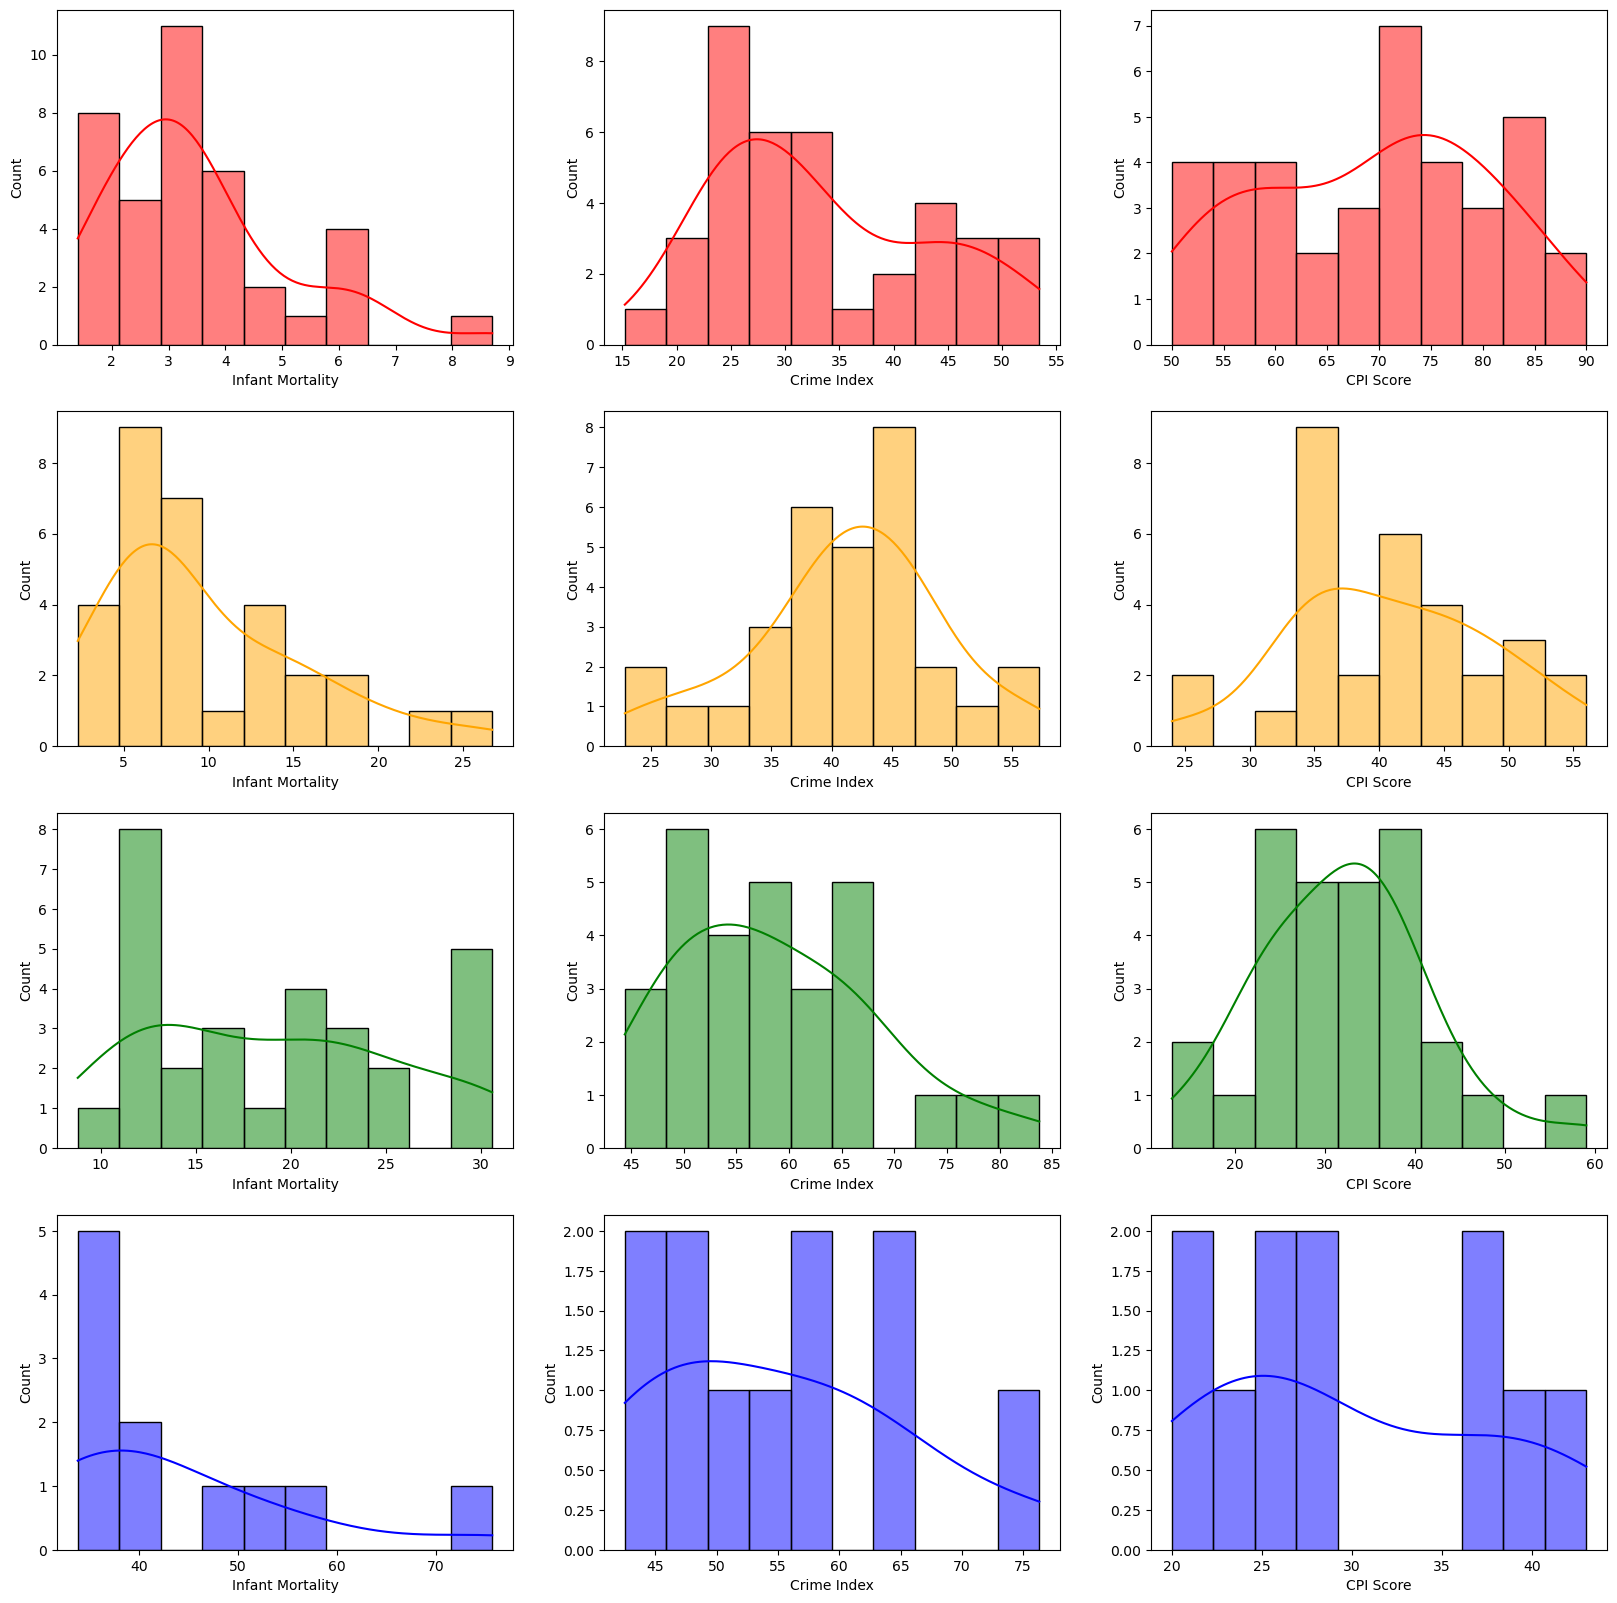

In [49]:
#Reuse the same function from earlier in the report to create clusters 

cluster_hist_graph(
    cluster = 'Safety Cluster', 
    var_list = ['Infant Mortality', 'Crime Index', 'CPI Score'], 
    colors_list = ['red', 'orange', 'green', 'blue'], 
    bins_num = 10, 
    kde_bool = True, 
    length = 20,
    width = 20, 
    x_graphs = 3, 
    y_graphs = 4,
)

Unlike the previous cluster, based on the histogram alone, we can see that none of the clusters are necessarily made up of outliers since they have a more spread out distributions. Here are some of the more important points to learn from this data: 

- Cluster 0 (red): By far the best performing cluster, with a low infant mortality where the kde peaks at around 3%, crime index kde peak of around 26, and a CPI score peak of around 75
- Cluster 1 (orange): Suffers the most from a poor CPI score, however, its infant mortality and relatively low in comparison to the other clusters
- Cluster 2 (green): Contains the worst CPI score with a significant peak of around 32. Its crime index distribution is very wide ranging from 45-84 with a peak of around 54 and a slightly higher infant mortality rate 
- Cluster 3 (blue): worst performing cluster overall, with the worst infant mortality rate, crime index, and CPI score even though the peaks aren't as significant. 

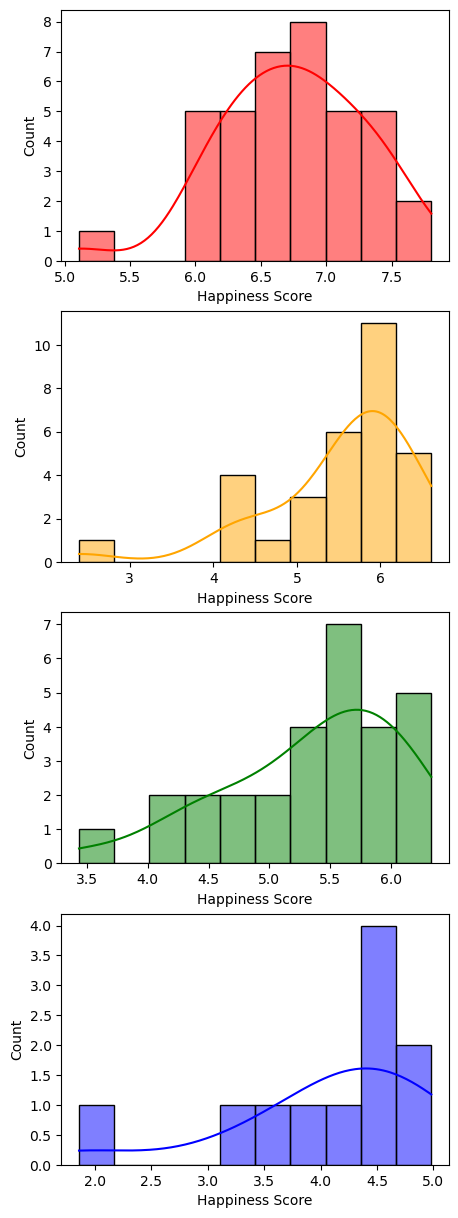

In [50]:
cluster_hist_graph(
    cluster = 'Safety Cluster', 
    var_list = ['Happiness Score'], 
    colors_list = ['red', 'orange', 'green', 'blue'], 
    bins_num = 10, 
    kde_bool = True, 
    length = 5,
    width = 15, 
    x_graphs = 1, 
    y_graphs = 4,
)

The happiness scores are very interesting for a variety of reasons listed here: 

- Cluster 3 has by far the worst happiness score overall. It's worth noting that its infant mortality was significantly higher than all other clusters by a large margin. While cluster 3 and cluster 1 both had somewhat similar CPI scores, this infant mortality was still the largest difference between the two
- Cluster 0 has the best happiness score since it was the best performing cluster in every aspect, just like cluster 3, its infant mortality had the biggest difference between the other clusters

/var/folders/9t/smb8cb7j223dk4xdg983zqmw0000gn/T/ipykernel_7293/557943936.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


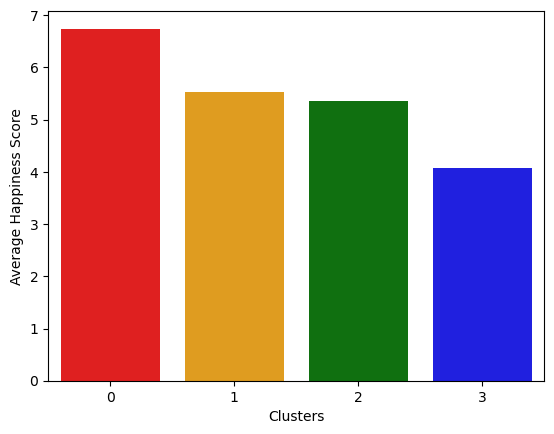

In [51]:
average_happiness_plot(
    cluster_names = ['0', '1', '2', '3'],
    cluster_type = 'Safety Cluster', 
    given_alpha = 1.0, 
    cluster_color_palette = ['red', 'orange', 'green', 'blue']
)

- Cluster 0 has the highest happiness score by a large difference in comparison to the other clusters while cluster 3 has the smallest. This is completely expected given that they both have the best and worst numbers overall. However, it's worth noting that infant mortality remains as the biggest difference between the two 
- Clusters 1 and 2 differ by a small amount with the largest difference between them being their crime index. This may indicate that crime index may not have as significant of an impact on happiness in comparison to other factors such as infant mortality. 

### Economy K-Means Clustering

In [52]:
scaled_econ_data = scaler.fit_transform(completeDf[['GDP ($)', 'Unemployment Rate',]])

test = KMeans(n_clusters = 4, random_state = 42)

econ_pred = test.fit_predict(scaled_econ_data)
econ_pred


array([3, 3, 3, 3, 1, 0, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 3, 2, 3, 3, 3,
       3, 0, 0, 0, 0, 3, 0, 0, 0, 3, 3, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 3,
       1, 0, 0, 3, 3, 0, 1, 0, 0, 3, 3, 3, 3, 0, 0, 0, 3, 0, 0, 0, 1, 3,
       0, 1, 0, 0, 0, 3, 3, 0, 0, 0, 0, 0, 0, 0, 3, 0, 0, 0, 1, 0, 0, 0,
       1, 0, 1, 0, 3, 0, 0, 0, 1, 1, 0, 3, 0, 0, 2, 3, 0, 3, 0, 3, 0],
      dtype=int32)

In [53]:
completeDf['Economics Cluster'] = econ_pred
completeDf.head()

,Country,Happiness Score,CO2-Emissions,GDP ($),Infant Mortality,Out of Pocket Health Expenditure (%),Physicians Per Thousand Citizens,Unemployment Rate,Crime Index,CPI Score,Health Cluster,Safety Cluster,Economics Cluster
0,Afghanistan,1.8590,8672,1.910135e+10,47.9,78.4,0.28,11.12,76.31,20,3,3,3
1,Albania,5.2773,4536,1.527808e+10,7.8,56.9,1.20,12.33,42.53,37,3,1,3
2,Algeria,5.3291,150006,1.699882e+11,20.1,28.1,1.72,11.70,52.03,36,1,2,3
3,Argentina,6.0237,201348,4.496634e+11,8.8,17.6,3.96,9.79,63.82,37,0,2,3
4,Armenia,5.3417,5156,1.367280e+10,11.0,81.6,4.40,16.99,22.79,47,3,1,1


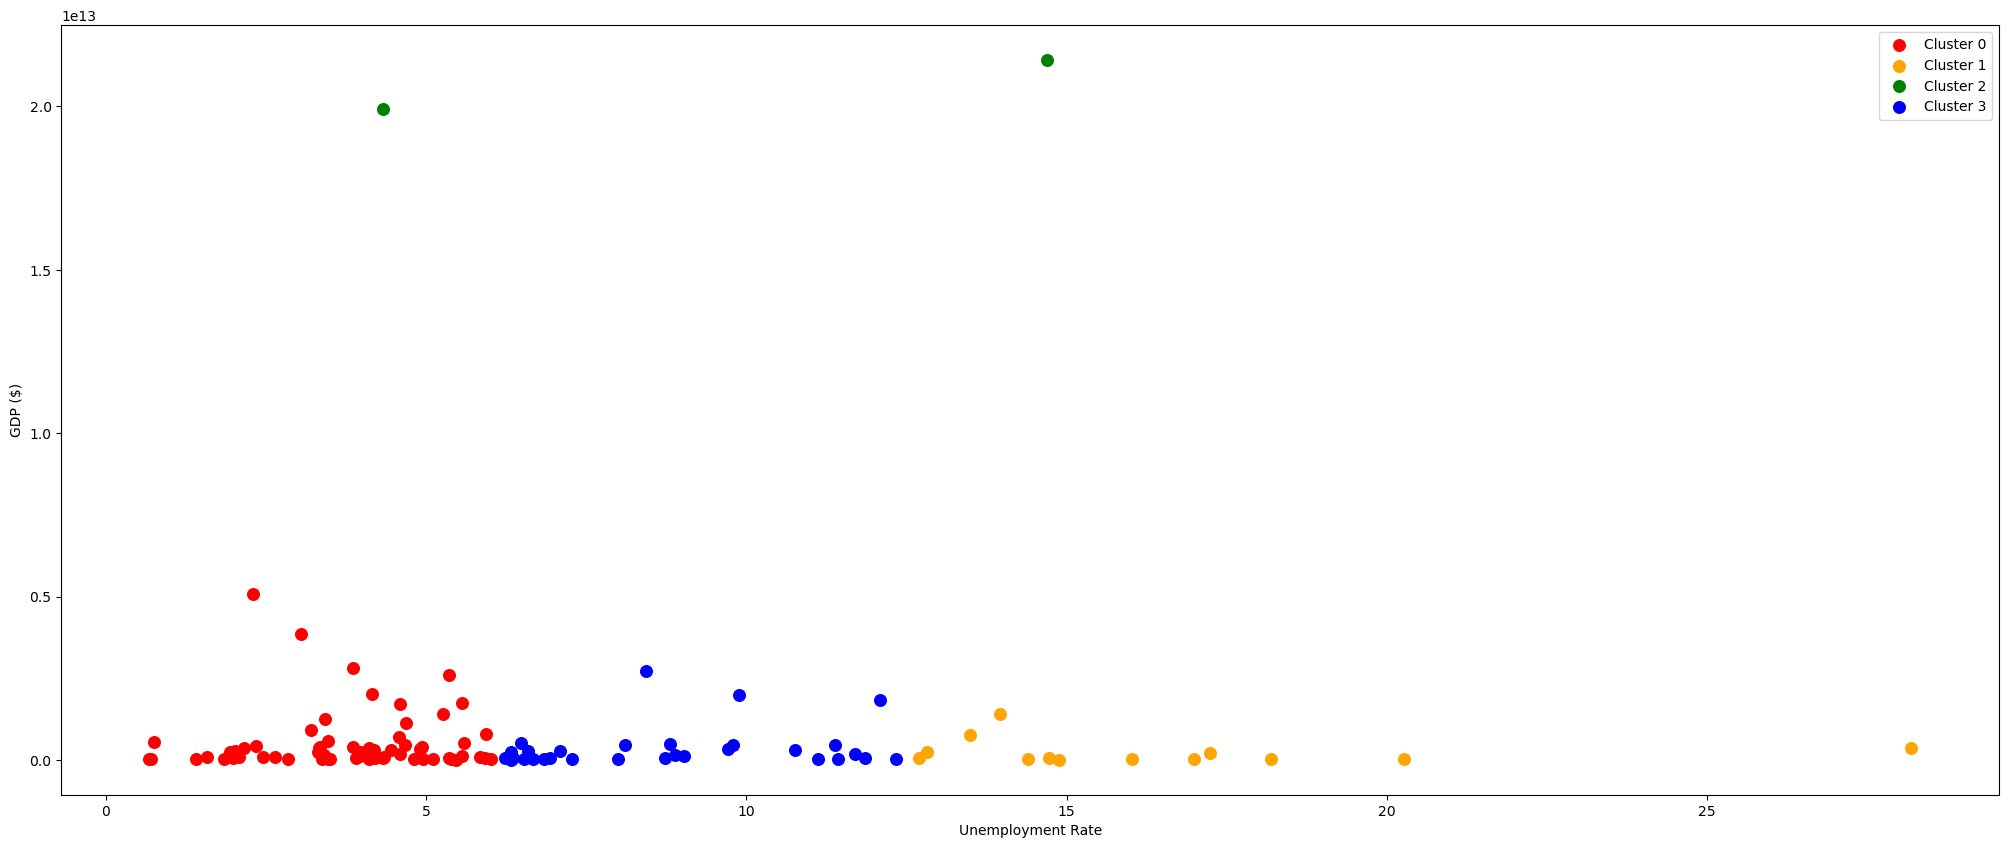

In [54]:
#Fix the size of the overall projections 
f, ax = plt.subplots(figsize = (25, 10))


#Create a list of colors for each color 
colors_list = ['red', 'orange', 'green', 'blue', 'purple']


#Loop that displays each color 
for i in range (0, 4, 1): 
    current_cluster = completeDf[completeDf['Economics Cluster'] == i]

    ax.scatter(
        x = current_cluster['Unemployment Rate'],
        y = current_cluster['GDP ($)'],
        color = colors_list[i],
        label = f'Cluster {i}',
        s = 70,
        alpha=1
    )

#Set axes labels and show legend
ax.set_xlabel('Unemployment Rate')
ax.set_ylabel('GDP ($)')



plt.legend()

Immediately off the bat, we can see how each country was sorted least to most unemployment. It is also evident that GDP didn't play a crucial role in this sorting since many of the points in each cluster have very similar numbers. 

The only thing that may be an issue is the cluster 2 points near the top that are obvious outliers. Since there is no good reason to invalidate these points, I have decided to keep them for the time being. 

In [55]:
completeDf.head()

,Country,Happiness Score,CO2-Emissions,GDP ($),Infant Mortality,Out of Pocket Health Expenditure (%),Physicians Per Thousand Citizens,Unemployment Rate,Crime Index,CPI Score,Health Cluster,Safety Cluster,Economics Cluster
0,Afghanistan,1.8590,8672,1.910135e+10,47.9,78.4,0.28,11.12,76.31,20,3,3,3
1,Albania,5.2773,4536,1.527808e+10,7.8,56.9,1.20,12.33,42.53,37,3,1,3
2,Algeria,5.3291,150006,1.699882e+11,20.1,28.1,1.72,11.70,52.03,36,1,2,3
3,Argentina,6.0237,201348,4.496634e+11,8.8,17.6,3.96,9.79,63.82,37,0,2,3
4,Armenia,5.3417,5156,1.367280e+10,11.0,81.6,4.40,16.99,22.79,47,3,1,1


#### Economics Cluster Analysis by Variable 

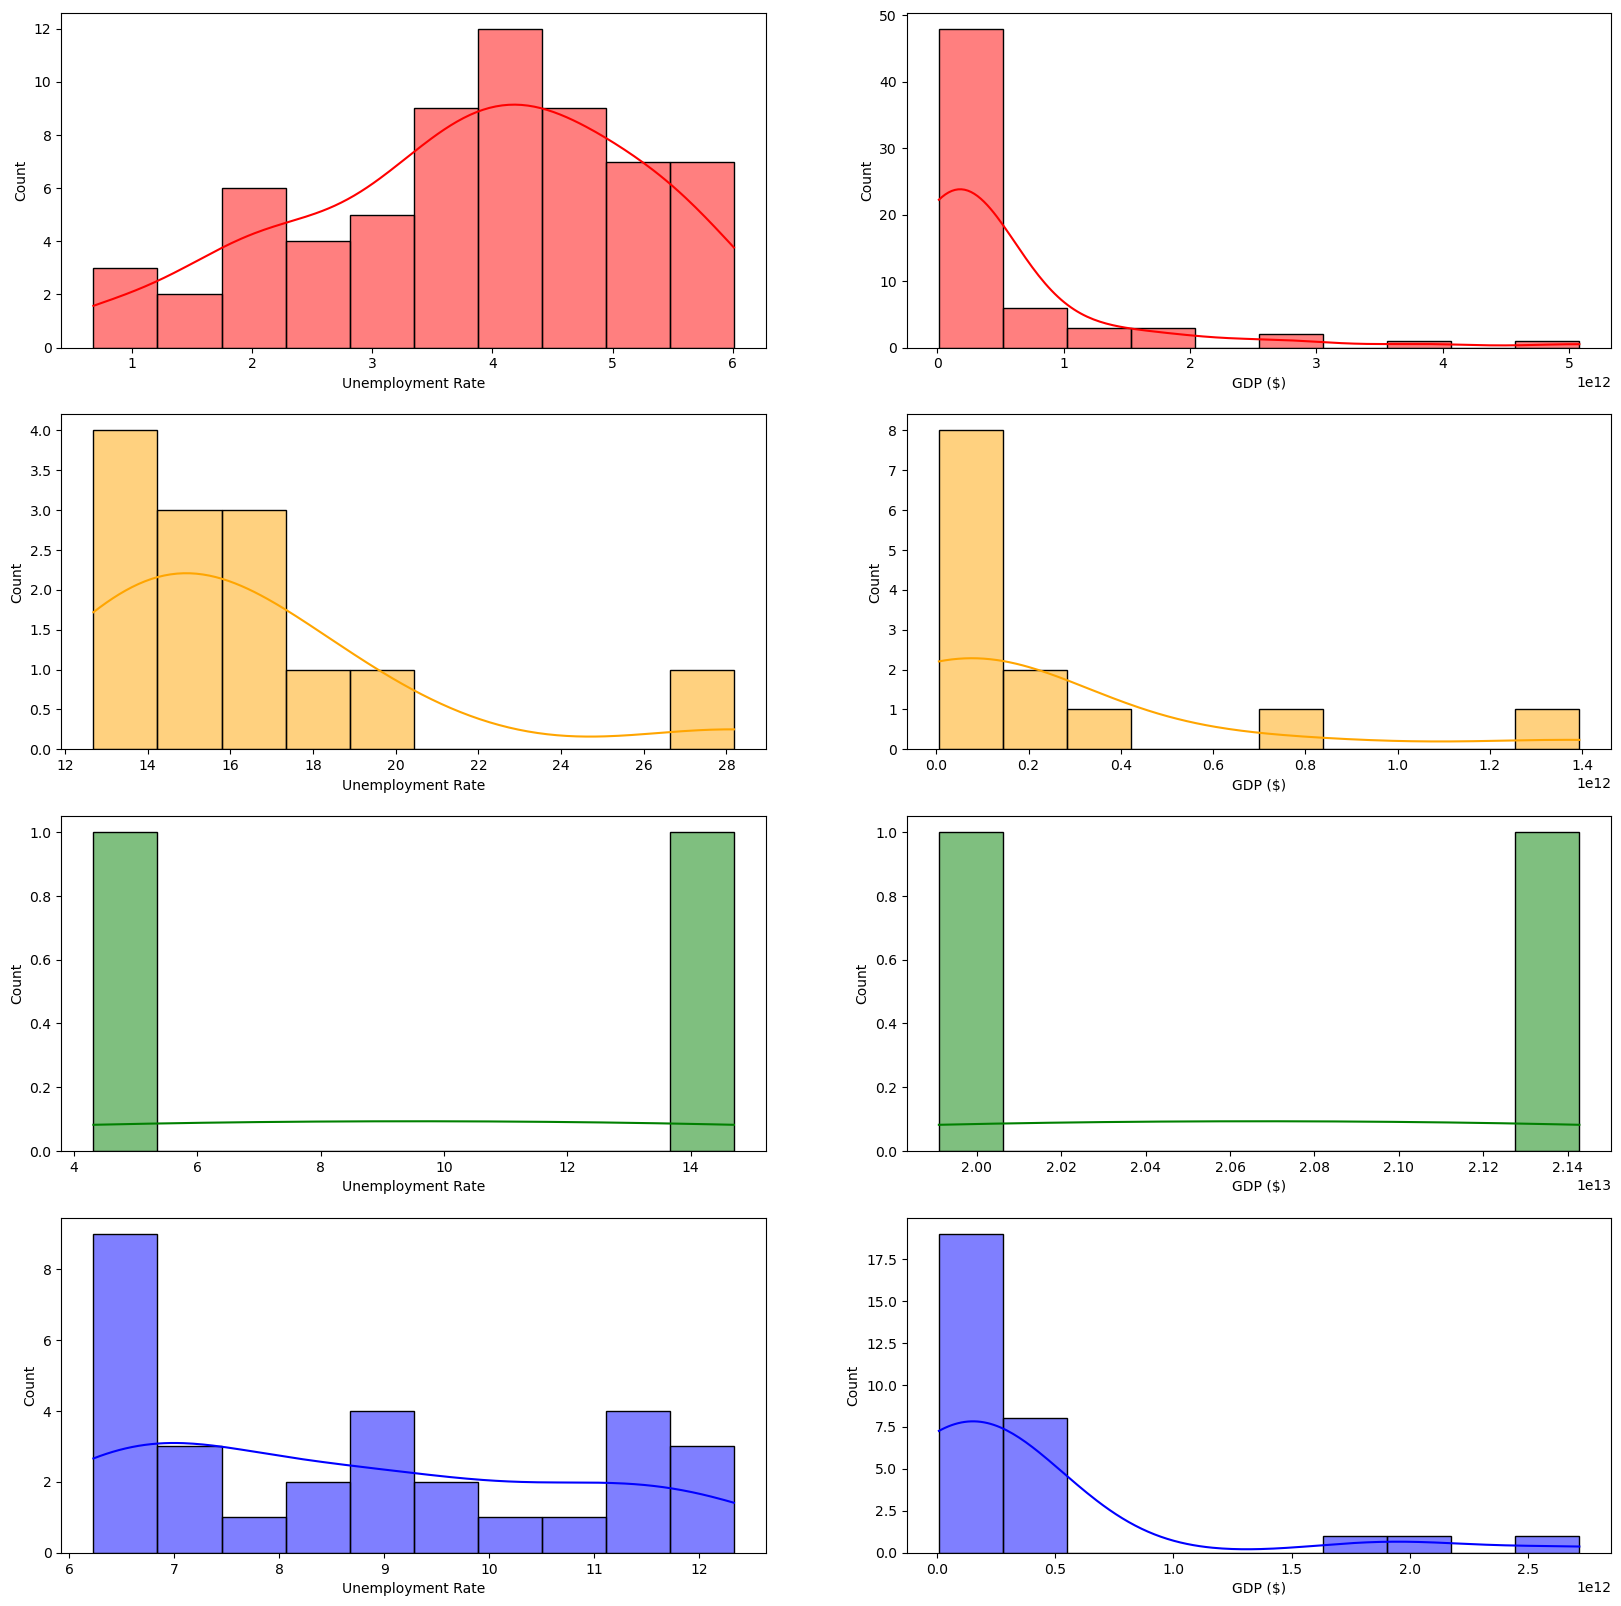

In [56]:
#Reuse the same function from earlier in the report to create clusters 
cluster_hist_graph(
    cluster = 'Economics Cluster', 
    var_list = ['Unemployment Rate', 'GDP ($)'], 
    colors_list = ['red', 'orange', 'green', 'blue', 'purple'], 
    bins_num = 10, 
    kde_bool = True, 
    length = 20,
    width = 20, 
    x_graphs = 2, 
    y_graphs = 4,
)


From the start, it's easy to tell how little variance there is in the GDP, which once again, is completely expected given the original, universal distribution for GDP. It should be expected to not see much variance in the clusters at all. With the little difference that there is, cluster 0 still remains as the richest cluster given its kde peak in comparison to others. 

Unfortunately, cluster 2 is once again only consisting of two countries, so there is not much inference we can obtain from this analysis. 

The other countries on the other hand have drastically different values when is comes to unemployment rates. Cluster 1 is the most unemployed cluster with a peak of around 15% and most of its data lying between 13-18%. Cluster 0 is the most employed cluster since its peak is around 4% with 6% being the highest possible value seen. 

#### Economics Cluster Happiness Analysis

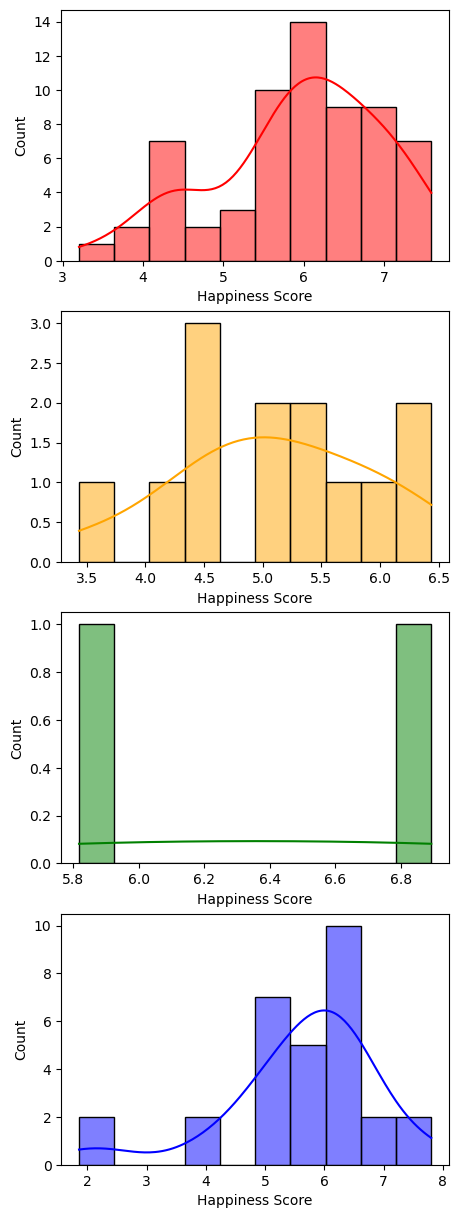

In [57]:
cluster_hist_graph(
    cluster = 'Economics Cluster', 
    var_list = ['Happiness Score'], 
    colors_list = ['red', 'orange', 'green', 'blue'], 
    bins_num = 10, 
    kde_bool = True, 
    length = 5,
    width = 15, 
    x_graphs = 1, 
    y_graphs = 4,
)

Overall, it is easy to tell that the happiness score in cluster 0 is the happiest with most of its countries lying between 5.5 - 7.5. This is noteworthy considering that it had the lowest unemployment rate out of all the countries. This and cluster 1 had a huge difference, considering that cluster 1 had a much higher unemployment rate than cluster 0 and has a lower happiness score by around 1 point.

/var/folders/9t/smb8cb7j223dk4xdg983zqmw0000gn/T/ipykernel_7293/557943936.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


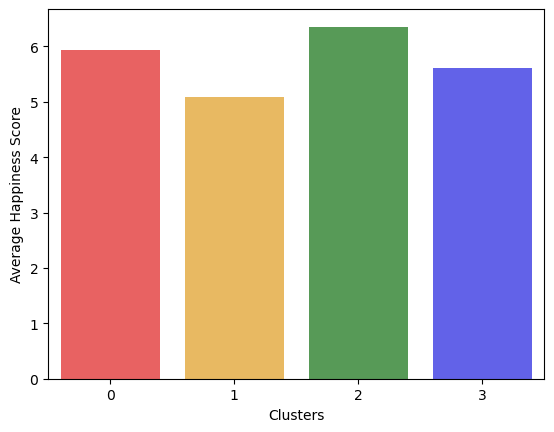

In [58]:
average_happiness_plot(
    cluster_names = ['0', '1', '2', '3'],
    cluster_type = 'Economics Cluster', 
    given_alpha = 0.7, 
    cluster_color_palette = ['red', 'orange', 'green', 'blue']
)

While cluster 2 has much higher average happiness, we come to the same problem that there is not enough countries to make an accurate assumption with this cluster. 

Cluster 0 on the other hand beats cluster 1 by around 1 point due to its impressive economical numbers. 

# Conlcusion

From the data and analysis shown, it is evident that infant mortality is by far the most influential factor when it comes to happiness. Off the bat, infant mortality had the most significant downward slope when visually looking at its correlation with happiness. The heatmap supports this idea by revealing a value of -0.68, the least value present on the map. Additionally, clusters were significantly affected by infant mortality such as cluster 2 in the citizen safety analysis, where it had a significantly higher infant mortality rate and both its happiness distribution and average happiness suffered because of it. 

There are a variety of reasons why this may be the case. For one, an infant dying may be the worst thing one can experience in life. Whether its in the perspective from a mother or other family member, it may be the worst experience one can have in life. Since multiple people ranging from friends and family members could be affected by this event, it may be the reason why it has the largest negative influence on a country's happiness.  

On the other side, the CPI score had the largest, positive influence on a country's happiness. It had the strongest positive correlation when being compared with happiness with an r-value of 0.70, also making it the largest value away from 0. In the k-means clustering section for the citizen safety category, clusters with a much higher CPI score tended to have a higher average happiness.

The reasoning behind this may have to do with feeling supported. If the government does not properly care for their citizens, then the people have every reason to feel isolate or left behind. Politics and the government alone can have a huge influence on other factors as well, such as one's income, health, mental health, and human rights. Without this, people with inevitably feel worse about themselves and their situation. 

# Things to Improve

I ran into a variety of issues throughout this project and there are plenty of things that I would've done better. For instance, I wish I had implemented more visual data using a map. Since geography played a huge role in this project, it would've been very beneficial to present a map and display which regions had higher happiness rates rather than just displaying it with just words. For future reference, geopandas seems like a great tool for this and helps display shape files for global data. 

I also wish that I had much more data. Since the beginning, I really wanted to incorporate various machine learning algorithms such as random forest regression to learn more about the patterns in the data. However, this did not end up working out since the test and training scores were difficult to manage, which makes sense that my algorithm was essentially memorizing the data, causing a high test score and incredibly low training score.

